# Evaluation Analytics (All Runs)

This notebook scans all `evaluation_results*.csv` files under a folder (default: A1 results), computes per-run analytics, and returns a summary table with:

- Switch directions (`DPDK → OAI`, `OAI → DPDK`)
- Scale events (`up`, `down`)
- Cooldown blockages
- Average SEC
- Total Power
- Violation rate
- Average QoS

In [27]:
from pathlib import Path
import re
import pandas as pd
import numpy as np
import yaml

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 180)

In [28]:
# ----- Configure this root folder -----
RUNS_ROOT = Path('../experiments/results/A1_policy_observation')
# ---------------------------------------

assert RUNS_ROOT.exists(), f'Folder not found: {RUNS_ROOT.resolve()}'
RUNS_ROOT

PosixPath('../experiments/results/A1_policy_observation')

In [42]:
def _extract_timestamp_from_name(path: Path) -> str:
    m = re.search(r'(\d{8}-\d{6})', path.name)
    return m.group(1) if m else ''


def find_latest_eval_csv_per_run(root: Path) -> dict[Path, Path]:
    """Return {run_dir: latest_evaluation_csv} for all runs under root."""
    all_csvs = sorted(root.rglob('evaluation_results*.csv'))
    latest = {}

    for csv_path in all_csvs:
        # expected layout: .../<config>/<seed>/eval/evaluation_results_*.csv
        if csv_path.parent.name != 'eval':
            continue
        run_dir = csv_path.parent.parent

        if run_dir not in latest:
            latest[run_dir] = csv_path
            continue

        current = latest[run_dir]
        t_new = _extract_timestamp_from_name(csv_path)
        t_old = _extract_timestamp_from_name(current)

        if t_new and t_old:
            if t_new > t_old:
                latest[run_dir] = csv_path
        else:
            # fallback: file modification time
            if csv_path.stat().st_mtime > current.stat().st_mtime:
                latest[run_dir] = csv_path

    return latest


def load_perf_threshold(run_dir: Path, default=0.9) -> float:
    cfg_path = run_dir / 'config.yaml'
    if not cfg_path.exists():
        return float(default)
    try:
        with open(cfg_path, 'r', encoding='utf-8') as f:
            cfg = yaml.safe_load(f)
        return float(cfg.get('environment', {}).get('performance_threshold', default))
    except Exception:
        return float(default)


def compute_run_metrics(eval_csv: Path) -> dict:
    df = pd.read_csv(eval_csv)
    run_dir = eval_csv.parent.parent

    # IDs from folder layout: .../<group>/<config>/<seed>/eval/file.csv
    group = run_dir.parents[1].name if len(run_dir.parents) >= 2 else ''
    config_name = run_dir.parents[0].name if len(run_dir.parents) >= 1 else ''
    seed_name = run_dir.name

    # Action series (executed path is what actually happened)
    if 'executed_action' in df.columns:
        action = pd.to_numeric(df['executed_action'], errors='coerce')
    elif 'executed_code' in df.columns:
        action = pd.to_numeric(df['executed_code'], errors='coerce')
    else:
        action = pd.Series([np.nan] * len(df))

    prev = action.shift(1)
    cur = action

    # Separate switch directions
    switch_dpdk_to_oai = int(((prev == 0) & (cur > 0)).sum())
    switch_oai_to_dpdk = int(((prev > 0) & (cur == 0)).sum())

    # Scale events strictly within OAI family only (exclude OAI->DPDK)
    scale_up = int(((prev > 0) & (cur > 0) & (cur > prev)).sum())
    scale_down = int(((prev > 0) & (cur > 0) & (cur < prev)).sum())

    # Cooldown blockage
    if 'cooldown_blocked' in df.columns:
        cooldown_blocked = int(df['cooldown_blocked'].fillna(False).astype(bool).sum())
    elif {'requested_action', 'executed_action'}.issubset(df.columns):
        req = pd.to_numeric(df['requested_action'], errors='coerce')
        exe = pd.to_numeric(df['executed_action'], errors='coerce')
        cooldown_blocked = int(req.ne(exe).fillna(False).sum())
    else:
        cooldown_blocked = 0

    # Avg SEC
    if 'sec' in df.columns:
        avg_sec = float(pd.to_numeric(df['sec'], errors='coerce').mean())
    else:
        p = pd.to_numeric(df.get('power'), errors='coerce')
        t = pd.to_numeric(df.get('traffic'), errors='coerce')
        avg_sec = float((p / np.maximum(t, 1e-6)).mean())

    # Total power and average QoS
    power = pd.to_numeric(df.get('power'), errors='coerce')
    qos = pd.to_numeric(df.get('performance'), errors='coerce')
    total_power = float(power.sum())
    avg_qos = float(qos.mean()) if 'performance' in df.columns else np.nan

    # Violation rate
    threshold = load_perf_threshold(run_dir, default=0.9)
    if 'performance' in df.columns:
        violation_rate = float((qos < threshold).mean())
    elif 'qos_penalty' in df.columns:
        qpen = pd.to_numeric(df['qos_penalty'], errors='coerce').fillna(0)
        violation_rate = float((qpen > 0).mean())
    else:
        violation_rate = np.nan

    return {
        'group': group,
        'config': config_name,
        'seed': seed_name,
        'run_dir': str(run_dir),
        'eval_csv': str(eval_csv),
        'steps': int(len(df)),
        'switch_dpdk_to_oai': switch_dpdk_to_oai,
        'switch_oai_to_dpdk': switch_oai_to_dpdk,
        'scale_up': scale_up,
        'scale_down': scale_down,
        'cooldown_blocked': cooldown_blocked,
        'avg_sec': avg_sec,
        'total_power': total_power,
        'violation_rate': violation_rate,
        'avg_qos': avg_qos,
        'qos_threshold': threshold,
    }

In [43]:
latest_per_run = find_latest_eval_csv_per_run(RUNS_ROOT)
print(f'Found {len(latest_per_run)} run(s) with evaluation CSVs under {RUNS_ROOT}')

rows = [compute_run_metrics(csv_path) for csv_path in sorted(latest_per_run.values())]
summary_df = pd.DataFrame(rows)

if summary_df.empty:
    print('No evaluation CSVs found.')
else:
    # Nice sort order
    summary_df = summary_df.sort_values(['group', 'config', 'seed']).reset_index(drop=True)

    # Display rounded view
    display_cols = [
        'group', 'config', 'seed', 'steps',
        'switch_dpdk_to_oai', 'switch_oai_to_dpdk',
        'scale_up', 'scale_down', 'cooldown_blocked',
        'avg_sec', 'total_power', 'violation_rate', 'avg_qos'
    ]

    display(summary_df[display_cols].round({
        'avg_sec': 6,
        'total_power': 3,
        'violation_rate': 4,
        'avg_qos': 4
    }))

Found 8 run(s) with evaluation CSVs under ../experiments/results/A1_policy_observation


,group,config,seed,steps,switch_dpdk_to_oai,switch_oai_to_dpdk,scale_up,scale_down,cooldown_blocked,avg_sec,total_power,violation_rate,avg_qos
0,A1_policy_observation,lstm_forecast,seed_456,721,0,0,0,0,0,0.013528,591.170,0.0000,0.9732
1,A1_policy_observation,lstm_history,seed_456,721,8,8,0,0,7,0.007641,502.975,0.0014,0.9552
2,A1_policy_observation,lstm_hybrid,seed_456,721,7,7,5,6,20,0.010073,529.530,0.0042,0.9643
3,A1_policy_observation,lstm_instant,seed_456,721,0,0,0,0,0,0.013528,591.170,0.0000,0.9732
4,A1_policy_observation,mlp_forecast,seed_456,721,7,8,16,17,79,0.007474,493.798,0.0014,0.9542
5,A1_policy_observation,mlp_history,seed_456,721,9,10,9,6,29,0.007388,488.826,0.0014,0.9520
6,A1_policy_observation,mlp_hybrid,seed_456,721,8,9,7,0,3,0.007350,483.160,0.0014,0.9547
7,A1_policy_observation,mlp_instant,seed_456,721,12,12,1,3,36,0.007374,484.122,0.0014,0.9549


In [31]:
# Optional: aggregate by config (across seeds)
if not summary_df.empty:
    agg = (
        summary_df.groupby(['group', 'config'], as_index=False)
        .agg({
            'switch_dpdk_to_oai': 'mean',
            'switch_oai_to_dpdk': 'mean',
            'scale_up': 'mean',
            'scale_down': 'mean',
            'cooldown_blocked': 'mean',
            'avg_sec': 'mean',
            'total_power': 'mean',
            'violation_rate': 'mean',
            'avg_qos': 'mean',
            'seed': 'count'
        })
        .rename(columns={'seed': 'n_runs'})
    )

    display(agg.round({
        'switch_dpdk_to_oai': 2,
        'switch_oai_to_dpdk': 2,
        'scale_up': 2,
        'scale_down': 2,
        'cooldown_blocked': 2,
        'avg_sec': 6,
        'total_power': 3,
        'violation_rate': 4,
        'avg_qos': 4
    }))

,group,config,switch_dpdk_to_oai,switch_oai_to_dpdk,scale_up,scale_down,cooldown_blocked,avg_sec,total_power,violation_rate,avg_qos,n_runs
0,A1_policy_observation,lstm_forecast,0.0,0.0,0.0,0.0,0.0,0.013528,591.170,0.0000,0.9732,1
1,A1_policy_observation,lstm_history,8.0,8.0,0.0,0.0,7.0,0.007641,502.975,0.0014,0.9552,1
2,A1_policy_observation,lstm_hybrid,7.0,7.0,5.0,6.0,20.0,0.010073,529.530,0.0042,0.9643,1
3,A1_policy_observation,lstm_instant,0.0,0.0,0.0,0.0,0.0,0.013528,591.170,0.0000,0.9732,1
4,A1_policy_observation,mlp_forecast,7.0,8.0,16.0,17.0,79.0,0.007474,493.798,0.0014,0.9542,1
5,A1_policy_observation,mlp_history,9.0,10.0,9.0,6.0,29.0,0.007388,488.826,0.0014,0.9520,1
6,A1_policy_observation,mlp_hybrid,8.0,9.0,7.0,0.0,3.0,0.007350,483.160,0.0014,0.9547,1
7,A1_policy_observation,mlp_instant,12.0,12.0,1.0,3.0,36.0,0.007374,484.122,0.0014,0.9549,1


In [32]:
# Save per-run analytics CSV
if not summary_df.empty:
    out_path = RUNS_ROOT / 'evaluation_analytics_summary.csv'
    summary_df.to_csv(out_path, index=False)
    print(f'Saved: {out_path}')

Saved: ../experiments/results/A1_policy_observation/evaluation_analytics_summary.csv


In [33]:
# Publication-ready comparative figures (Elsevier-style)
# These figures use static, high-resolution formatting suitable for telecom journal manuscripts.
# Run the previous summary cells first so `summary_df` is available.

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

assert 'summary_df' in globals() and not summary_df.empty, "Run the analytics summary cells first to create summary_df"

paper_dir = RUNS_ROOT / "paper_figures"
paper_dir.mkdir(parents=True, exist_ok=True)

# Journal-friendly style
sns.set_theme(style="whitegrid", context="paper")
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})

metrics_all = [
    'switch_dpdk_to_oai', 'switch_oai_to_dpdk',
    'scale_up', 'scale_down', 'cooldown_blocked',
    'avg_sec', 'total_power', 'violation_rate', 'avg_qos'
]

cfg_mean = summary_df.groupby(['group', 'config'], as_index=False)[metrics_all].mean()
cfg_std = summary_df.groupby(['group', 'config'], as_index=False)[metrics_all].std().fillna(0.0)
cfg_n = summary_df.groupby(['group', 'config'], as_index=False).size().rename(columns={'size': 'n_runs'})

cfg_stats = cfg_mean.merge(cfg_std, on=['group', 'config'], suffixes=('_mean', '_std')).merge(cfg_n, on=['group', 'config'])

cfg_stats['label'] = np.where(
    cfg_stats['group'].nunique() > 1,
    cfg_stats['group'] + ' | ' + cfg_stats['config'],
    cfg_stats['config']
)

cfg_stats

,group,config,switch_dpdk_to_oai_mean,switch_oai_to_dpdk_mean,scale_up_mean,scale_down_mean,cooldown_blocked_mean,avg_sec_mean,total_power_mean,violation_rate_mean,avg_qos_mean,switch_dpdk_to_oai_std,switch_oai_to_dpdk_std,scale_up_std,scale_down_std,cooldown_blocked_std,avg_sec_std,total_power_std,violation_rate_std,avg_qos_std,n_runs,label
0,A1_policy_observation,lstm_forecast,0.0,0.0,0.0,0.0,0.0,0.013528,591.169839,0.000000,0.973202,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,lstm_forecast
1,A1_policy_observation,lstm_history,8.0,8.0,0.0,0.0,7.0,0.007641,502.974575,0.001387,0.955212,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,lstm_history
2,A1_policy_observation,lstm_hybrid,7.0,7.0,5.0,6.0,20.0,0.010073,529.530100,0.004161,0.964272,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,lstm_hybrid
3,A1_policy_observation,lstm_instant,0.0,0.0,0.0,0.0,0.0,0.013528,591.169839,0.000000,0.973202,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,lstm_instant
4,A1_policy_observation,mlp_forecast,7.0,8.0,16.0,17.0,79.0,0.007474,493.798125,0.001387,0.954193,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,mlp_forecast
5,A1_policy_observation,mlp_history,9.0,10.0,9.0,6.0,29.0,0.007388,488.826349,0.001387,0.951955,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,mlp_history
6,A1_policy_observation,mlp_hybrid,8.0,9.0,7.0,0.0,3.0,0.007350,483.160035,0.001387,0.954665,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,mlp_hybrid
7,A1_policy_observation,mlp_instant,12.0,12.0,1.0,3.0,36.0,0.007374,484.122008,0.001387,0.954939,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,mlp_instant


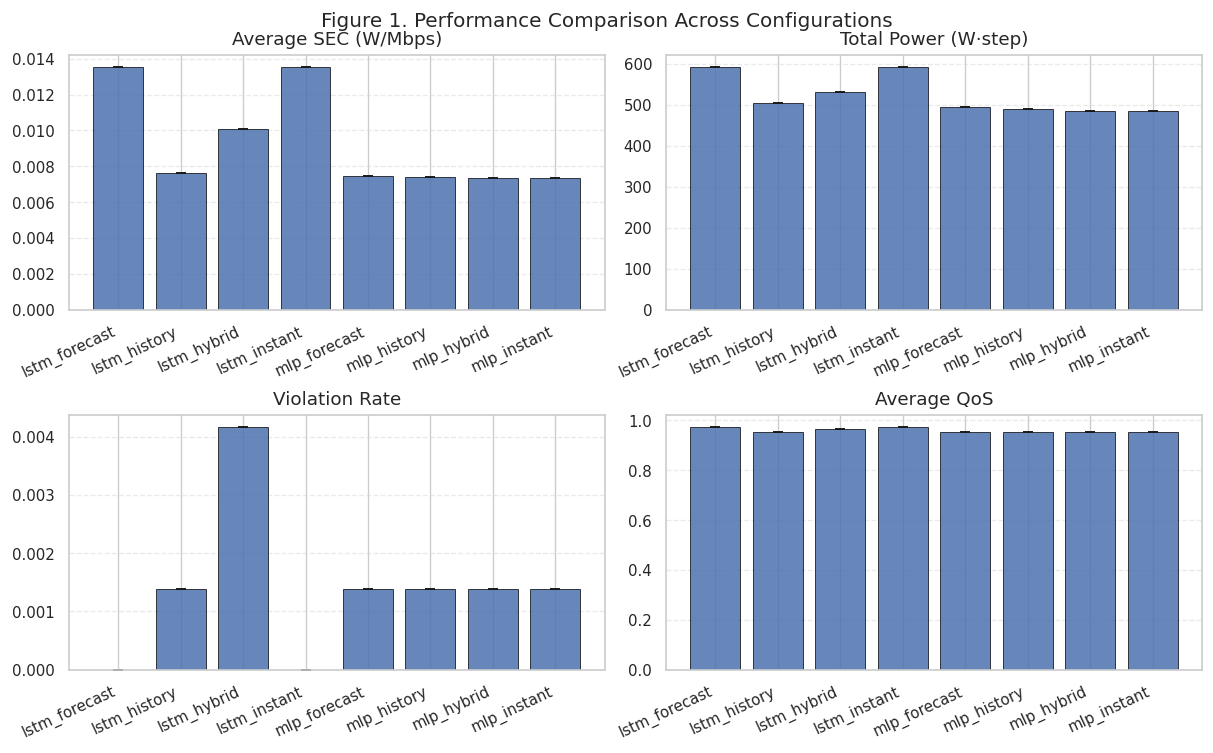

Saved: ../experiments/results/A1_policy_observation/paper_figures/fig1_performance_comparison.png
Saved: ../experiments/results/A1_policy_observation/paper_figures/fig1_performance_comparison.pdf


In [35]:
# Figure 1: Core performance comparison (mean ± std)
fig, axes = plt.subplots(2, 2, figsize=(10, 6), constrained_layout=True)

plot_specs = [
    ('avg_sec', 'Average SEC (W/Mbps)'),
    ('total_power', 'Total Power (W·step)'),
    ('violation_rate', 'Violation Rate'),
    ('avg_qos', 'Average QoS'),
]

x = np.arange(len(cfg_stats))
labels = cfg_stats['label'].tolist()

for ax, (metric, title) in zip(axes.flat, plot_specs):
    m = cfg_stats[f'{metric}_mean'].to_numpy()
    s = cfg_stats[f'{metric}_std'].to_numpy()

    ax.bar(x, m, yerr=s, capsize=3, color='#4C72B0', alpha=0.85, edgecolor='black', linewidth=0.5)
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=25, ha='right')
    ax.grid(axis='y', linestyle='--', alpha=0.4)

fig.suptitle('Figure 1. Performance Comparison Across Configurations', y=1.02)

fig1_png = paper_dir / 'fig1_performance_comparison.png'
fig1_pdf = paper_dir / 'fig1_performance_comparison.pdf'
fig.savefig(fig1_png, bbox_inches='tight')
fig.savefig(fig1_pdf, bbox_inches='tight')
plt.show()

print(f'Saved: {fig1_png}')
print(f'Saved: {fig1_pdf}')

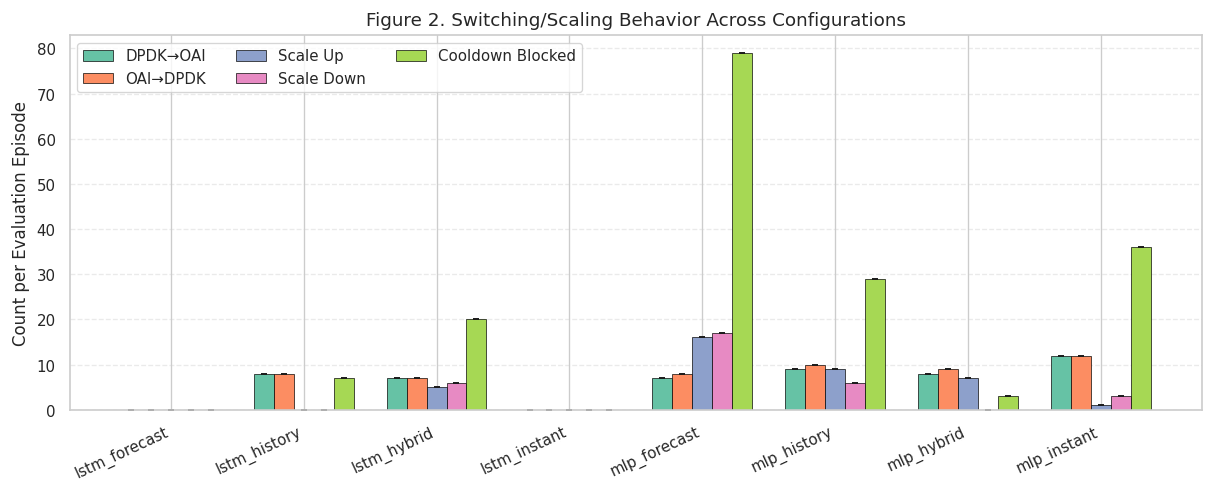

Saved: ../experiments/results/A1_policy_observation/paper_figures/fig2_action_dynamics.png
Saved: ../experiments/results/A1_policy_observation/paper_figures/fig2_action_dynamics.pdf


In [36]:
# Figure 2: Action dynamics comparison (mean ± std)
fig, ax = plt.subplots(figsize=(10, 4), constrained_layout=True)

event_metrics = [
    'switch_dpdk_to_oai',
    'switch_oai_to_dpdk',
    'scale_up',
    'scale_down',
    'cooldown_blocked',
]

event_labels = ['DPDK→OAI', 'OAI→DPDK', 'Scale Up', 'Scale Down', 'Cooldown Blocked']

x = np.arange(len(cfg_stats))
width = 0.15
offsets = np.linspace(-2, 2, len(event_metrics)) * width

palette = sns.color_palette('Set2', n_colors=len(event_metrics))

for i, (metric, lab) in enumerate(zip(event_metrics, event_labels)):
    m = cfg_stats[f'{metric}_mean'].to_numpy()
    s = cfg_stats[f'{metric}_std'].to_numpy()
    ax.bar(x + offsets[i], m, width=width, yerr=s, capsize=2, label=lab,
           color=palette[i], edgecolor='black', linewidth=0.4)

ax.set_title('Figure 2. Switching/Scaling Behavior Across Configurations')
ax.set_ylabel('Count per Evaluation Episode')
ax.set_xticks(x)
ax.set_xticklabels(cfg_stats['label'].tolist(), rotation=25, ha='right')
ax.legend(ncol=3, frameon=True)
ax.grid(axis='y', linestyle='--', alpha=0.4)

fig2_png = paper_dir / 'fig2_action_dynamics.png'
fig2_pdf = paper_dir / 'fig2_action_dynamics.pdf'
fig.savefig(fig2_png, bbox_inches='tight')
fig.savefig(fig2_pdf, bbox_inches='tight')
plt.show()

print(f'Saved: {fig2_png}')
print(f'Saved: {fig2_pdf}')

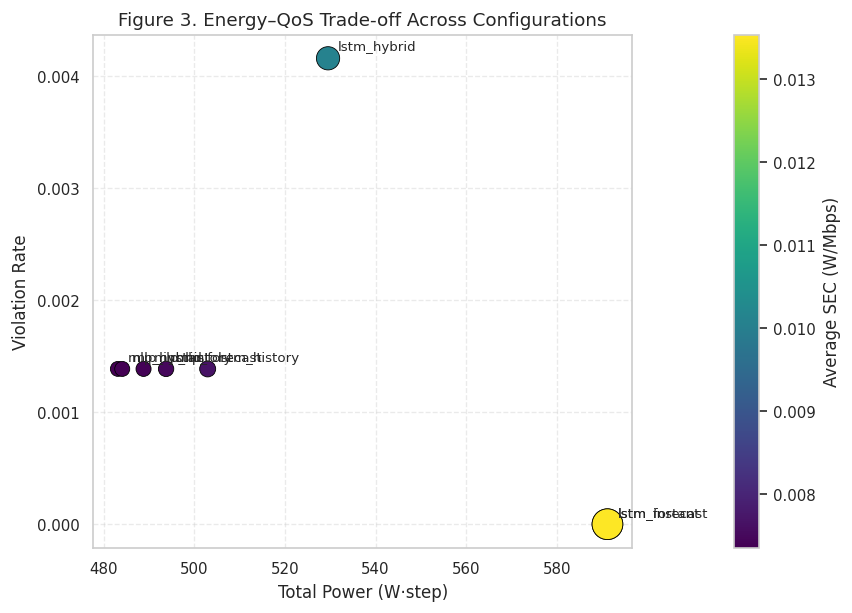

Saved: ../experiments/results/A1_policy_observation/paper_figures/fig3_energy_qos_tradeoff.png
Saved: ../experiments/results/A1_policy_observation/paper_figures/fig3_energy_qos_tradeoff.pdf


In [37]:
# Figure 3: Energy–QoS trade-off (Pareto-style view)
fig, ax = plt.subplots(figsize=(7, 5), constrained_layout=True)

x = cfg_stats['total_power_mean'].to_numpy()
y = cfg_stats['violation_rate_mean'].to_numpy()
xerr = cfg_stats['total_power_std'].to_numpy()
yerr = cfg_stats['violation_rate_std'].to_numpy()

# Bubble size from avg_sec (scaled)
sec = cfg_stats['avg_sec_mean'].to_numpy()
sec_norm = (sec - sec.min()) / (sec.max() - sec.min() + 1e-12)
sizes = 80 + 260 * sec_norm

ax.errorbar(x, y, xerr=xerr, yerr=yerr, fmt='none', ecolor='gray', elinewidth=0.8, alpha=0.8, zorder=1)
scatter = ax.scatter(x, y, s=sizes, c=sec, cmap='viridis', edgecolor='black', linewidth=0.5, zorder=2)

for _, row in cfg_stats.iterrows():
    ax.annotate(row['label'], (row['total_power_mean'], row['violation_rate_mean']),
                textcoords='offset points', xytext=(6, 5), fontsize=8)

cbar = fig.colorbar(scatter, ax=ax)
cbar.set_label('Average SEC (W/Mbps)')

ax.set_title('Figure 3. Energy–QoS Trade-off Across Configurations')
ax.set_xlabel('Total Power (W·step)')
ax.set_ylabel('Violation Rate')
ax.grid(True, linestyle='--', alpha=0.4)

fig3_png = paper_dir / 'fig3_energy_qos_tradeoff.png'
fig3_pdf = paper_dir / 'fig3_energy_qos_tradeoff.pdf'
fig.savefig(fig3_png, bbox_inches='tight')
fig.savefig(fig3_pdf, bbox_inches='tight')
plt.show()

print(f'Saved: {fig3_png}')
print(f'Saved: {fig3_pdf}')

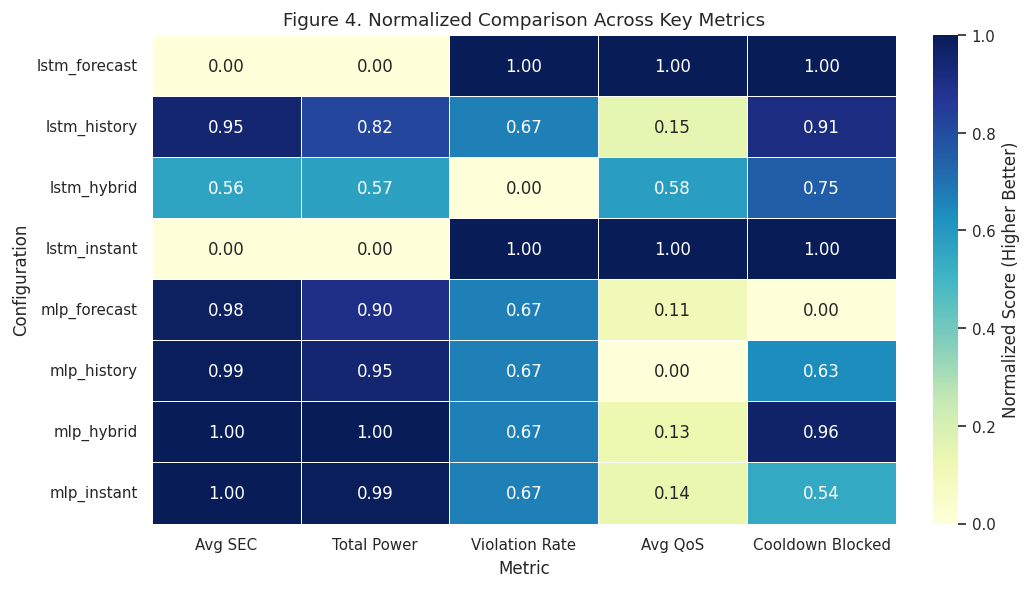

Saved: ../experiments/results/A1_policy_observation/paper_figures/fig4_normalized_heatmap.png
Saved: ../experiments/results/A1_policy_observation/paper_figures/fig4_normalized_heatmap.pdf


In [38]:
# Figure 4: Normalized multi-metric heatmap (higher score = better)
fig, ax = plt.subplots(figsize=(8.5, 4.8), constrained_layout=True)

heat_metrics = {
    'avg_sec_mean': 'Avg SEC',
    'total_power_mean': 'Total Power',
    'violation_rate_mean': 'Violation Rate',
    'avg_qos_mean': 'Avg QoS',
    'cooldown_blocked_mean': 'Cooldown Blocked',
}

score_df = cfg_stats[['label'] + list(heat_metrics.keys())].copy().set_index('label')

# Convert to normalized "better" scores in [0, 1]
lower_better = {'avg_sec_mean', 'total_power_mean', 'violation_rate_mean', 'cooldown_blocked_mean'}
for col in score_df.columns:
    col_min, col_max = score_df[col].min(), score_df[col].max()
    norm = (score_df[col] - col_min) / (col_max - col_min + 1e-12)
    if col in lower_better:
        score_df[col] = 1.0 - norm
    else:
        score_df[col] = norm

score_df = score_df.rename(columns=heat_metrics)

sns.heatmap(score_df, annot=True, fmt='.2f', cmap='YlGnBu', linewidths=0.4, cbar_kws={'label': 'Normalized Score (Higher Better)'}, ax=ax)
ax.set_title('Figure 4. Normalized Comparison Across Key Metrics')
ax.set_xlabel('Metric')
ax.set_ylabel('Configuration')

fig4_png = paper_dir / 'fig4_normalized_heatmap.png'
fig4_pdf = paper_dir / 'fig4_normalized_heatmap.pdf'
fig.savefig(fig4_png, bbox_inches='tight')
fig.savefig(fig4_pdf, bbox_inches='tight')
plt.show()

print(f'Saved: {fig4_png}')
print(f'Saved: {fig4_pdf}')

## Grouped summaries by Policy and Observation

This section enriches each run with `policy` and `observation` from the run `config.yaml` (fallback to parsing the config name), then provides separate aggregated tables.

In [39]:
assert 'summary_df' in globals() and not summary_df.empty, "Run the summary cells first to create summary_df"


def _policy_obs_from_run_dir(run_dir_str: str, config_name: str):
    run_dir = Path(run_dir_str)
    cfg_path = run_dir / 'config.yaml'

    policy = None
    observation = None

    if cfg_path.exists():
        try:
            with open(cfg_path, 'r', encoding='utf-8') as f:
                cfg = yaml.safe_load(f)
            policy = cfg.get('agent', {}).get('policy')
            observation = cfg.get('environment', {}).get('observation_schema')
        except Exception:
            pass

    # Fallback parse from config label like lstm_forecast, mlp_history, ...
    if policy is None or observation is None:
        parts = str(config_name).split('_')
        if len(parts) >= 2:
            model_token = parts[0].lower()
            obs_token = parts[1].lower()

            if policy is None:
                if model_token == 'lstm':
                    policy = 'MlpLstmPolicy'
                elif model_token == 'mlp':
                    policy = 'MlpPolicy'
                else:
                    policy = parts[0]

            if observation is None:
                observation = obs_token

    policy = policy if policy is not None else 'unknown_policy'
    observation = observation if observation is not None else 'unknown_observation'
    return policy, observation


summary_ext = summary_df.copy()
summary_ext[['policy', 'observation']] = summary_ext.apply(
    lambda r: pd.Series(_policy_obs_from_run_dir(r['run_dir'], r['config'])), axis=1
)

base_metrics = [
    'switch_dpdk_to_oai', 'switch_oai_to_dpdk',
    'scale_up', 'scale_down', 'cooldown_blocked',
    'avg_sec', 'total_power', 'violation_rate', 'avg_qos'
]


def _group_summary(df: pd.DataFrame, key: str) -> pd.DataFrame:
    g = (
        df.groupby(key)[base_metrics]
        .agg(['mean', 'std'])
        .reset_index()
    )
    g.columns = [key] + [f"{c[0]}_{c[1]}" for c in g.columns[1:]]
    n = df.groupby(key).size().reset_index(name='n_runs')
    return g.merge(n, on=key).sort_values(key).reset_index(drop=True)


policy_summary = _group_summary(summary_ext, 'policy')
obs_summary = _group_summary(summary_ext, 'observation')

print('Grouped by policy:')
display(policy_summary.round(4))

print('Grouped by observation:')
display(obs_summary.round(4))

policy_csv = RUNS_ROOT / 'evaluation_analytics_by_policy.csv'
obs_csv = RUNS_ROOT / 'evaluation_analytics_by_observation.csv'
policy_summary.to_csv(policy_csv, index=False)
obs_summary.to_csv(obs_csv, index=False)

print(f'Saved: {policy_csv}')
print(f'Saved: {obs_csv}')

Grouped by policy:


,policy,switch_dpdk_to_oai_mean,switch_dpdk_to_oai_std,switch_oai_to_dpdk_mean,switch_oai_to_dpdk_std,scale_up_mean,scale_up_std,scale_down_mean,scale_down_std,cooldown_blocked_mean,cooldown_blocked_std,avg_sec_mean,avg_sec_std,total_power_mean,total_power_std,violation_rate_mean,violation_rate_std,avg_qos_mean,avg_qos_std,n_runs
0,MlpLstmPolicy,3.75,4.3493,3.75,4.3493,1.25,2.5000,1.5,3.0000,6.75,9.4296,0.0112,0.0029,553.7111,44.5916,0.0014,0.002,0.9665,0.0086,4
1,MlpPolicy,9.00,2.1602,9.75,1.7078,8.25,6.1847,6.5,7.4162,36.75,31.5423,0.0074,0.0001,487.4766,4.8877,0.0014,0.000,0.9539,0.0014,4


Grouped by observation:


,observation,switch_dpdk_to_oai_mean,switch_dpdk_to_oai_std,switch_oai_to_dpdk_mean,switch_oai_to_dpdk_std,scale_up_mean,scale_up_std,scale_down_mean,scale_down_std,cooldown_blocked_mean,cooldown_blocked_std,avg_sec_mean,avg_sec_std,total_power_mean,total_power_std,violation_rate_mean,violation_rate_std,avg_qos_mean,avg_qos_std,n_runs
0,forecast,3.5,4.9497,4.0,5.6569,8.0,11.3137,8.5,12.0208,39.5,55.8614,0.0105,0.0043,542.4840,68.8522,0.0007,0.001,0.9637,0.0134,2
1,history,8.5,0.7071,9.0,1.4142,4.5,6.3640,3.0,4.2426,18.0,15.5563,0.0075,0.0002,495.9005,10.0043,0.0014,0.000,0.9536,0.0023,2
2,hybrid,7.5,0.7071,8.0,1.4142,6.0,1.4142,3.0,4.2426,11.5,12.0208,0.0087,0.0019,506.3451,32.7886,0.0028,0.002,0.9595,0.0068,2
3,instant,6.0,8.4853,6.0,8.4853,0.5,0.7071,1.5,2.1213,18.0,25.4558,0.0105,0.0044,537.6459,75.6942,0.0007,0.001,0.9641,0.0129,2


Saved: ../experiments/results/A1_policy_observation/evaluation_analytics_by_policy.csv
Saved: ../experiments/results/A1_policy_observation/evaluation_analytics_by_observation.csv


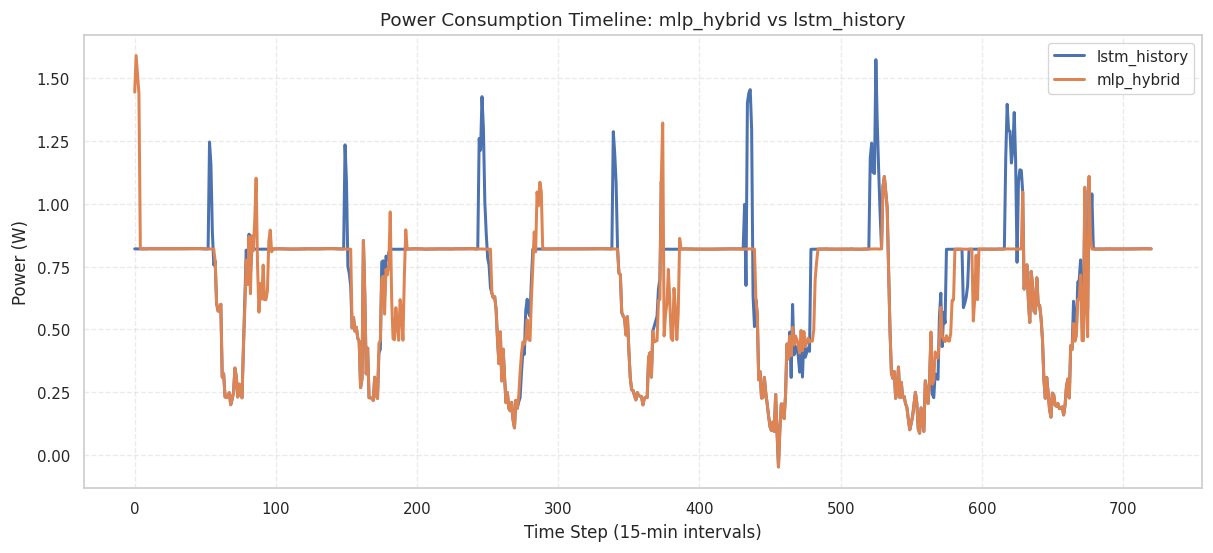

Saved: ../experiments/results/A1_policy_observation/paper_figures/fig_power_timeline_mlp_hybrid_vs_lstm_history.png
Saved: ../experiments/results/A1_policy_observation/paper_figures/fig_power_timeline_mlp_hybrid_vs_lstm_history.pdf


In [40]:
# Power timeline comparison: mlp_hybrid vs lstm_history
assert 'summary_df' in globals() and not summary_df.empty, "Run the summary cells first to create summary_df"

models_to_plot = ['mlp_hybrid', 'lstm_history']

subset = summary_df[summary_df['config'].isin(models_to_plot)].copy()
if subset.empty:
    raise ValueError(f"No rows found for models: {models_to_plot}")

# pick one row per model (latest eval csv if multiple exist)
subset = subset.sort_values(['config', 'eval_csv']).drop_duplicates(subset=['config'], keep='last')

fig, ax = plt.subplots(figsize=(10, 4.5), constrained_layout=True)

for _, row in subset.iterrows():
    eval_path = Path(row['eval_csv'])
    if not eval_path.exists():
        eval_path = (Path.cwd() / row['eval_csv']).resolve()

    df_run = pd.read_csv(eval_path)
    power = pd.to_numeric(df_run['power'], errors='coerce')
    t = np.arange(len(power))

    ax.plot(t, power, linewidth=1.8, label=row['config'])

ax.set_title('Power Consumption Timeline: mlp_hybrid vs lstm_history')
ax.set_xlabel('Time Step (15-min intervals)')
ax.set_ylabel('Power (W)')
ax.grid(True, linestyle='--', alpha=0.4)
ax.legend(frameon=True)

# Save figure
paper_dir = RUNS_ROOT / 'paper_figures'
paper_dir.mkdir(parents=True, exist_ok=True)

fig_path_png = paper_dir / 'fig_power_timeline_mlp_hybrid_vs_lstm_history.png'
fig_path_pdf = paper_dir / 'fig_power_timeline_mlp_hybrid_vs_lstm_history.pdf'
fig.savefig(fig_path_png, bbox_inches='tight')
fig.savefig(fig_path_pdf, bbox_inches='tight')

plt.show()

print(f'Saved: {fig_path_png}')
print(f'Saved: {fig_path_pdf}')

## Two-model summary table (mlp_hybrid vs lstm_history)

Requested metrics:
- Number of reconfigurations (= total switches)
- Number of scaling events
- Total energy (Wh)
- Average SEC
- QoS violation rate

In [44]:
assert 'summary_df' in globals() and not summary_df.empty, "Run the summary cells first to create summary_df"

models = ['mlp_hybrid', 'lstm_history']
step_hours = 0.25  # 15-minute interval

two_model = summary_df[summary_df['config'].isin(models)].copy()
if two_model.empty:
    raise ValueError(f"No rows found for models: {models}")

# One row per model (use latest eval CSV if multiple rows exist)
two_model = two_model.sort_values(['config', 'eval_csv']).drop_duplicates(subset=['config'], keep='last').copy()

# Requested metrics
two_model['number_of_reconfigurations'] = two_model['switch_dpdk_to_oai'] + two_model['switch_oai_to_dpdk']
two_model['number_of_scaling_events'] = two_model['scale_up'] + two_model['scale_down']
two_model['total_energy_wh'] = two_model['total_power'] * step_hours

summary_two = two_model[[
    'config',
    'number_of_reconfigurations',
    'number_of_scaling_events',
    'total_energy_wh',
    'avg_sec',
    'violation_rate'
]].rename(columns={
    'config': 'model',
    'avg_sec': 'average_sec',
    'violation_rate': 'qos_violation_rate'
}).sort_values('model').reset_index(drop=True)

display(summary_two.round({
    'total_energy_wh': 3,
    'average_sec': 6,
    'qos_violation_rate': 4
}))

out_two = RUNS_ROOT / 'evaluation_two_model_summary_mlp_hybrid_vs_lstm_history.csv'
summary_two.to_csv(out_two, index=False)
print(f'Saved: {out_two}')

,model,number_of_reconfigurations,number_of_scaling_events,total_energy_wh,average_sec,qos_violation_rate
0,lstm_history,16,0,125.744,0.007641,0.0014
1,mlp_hybrid,17,7,120.790,0.007350,0.0014


,model,number_of_reconfigurations,number_of_scaling_events,total_energy_wh,average_sec,qos_violation_rate
0,lstm_history,16,0,125.744,0.007641,0.0014
1,mlp_hybrid,17,7,120.790,0.007350,0.0014


Saved: ../experiments/results/A1_policy_observation/evaluation_two_model_summary_mlp_hybrid_vs_lstm_history.csv


In [45]:
# Compare mlp_hybrid vs lstm_history (analysis + winner table)
assert 'summary_df' in globals() and not summary_df.empty, "Run the summary cells first"

models = ['mlp_hybrid', 'lstm_history']
step_hours = 0.25  # 15-min step

cmp_df = summary_df[summary_df['config'].isin(models)].copy()
if cmp_df.empty:
    raise ValueError(f"No rows found for models: {models}")

# Derived metrics
cmp_df['number_of_reconfigurations'] = cmp_df['switch_dpdk_to_oai'] + cmp_df['switch_oai_to_dpdk']
cmp_df['number_of_scaling_events'] = cmp_df['scale_up'] + cmp_df['scale_down']
cmp_df['total_energy_wh'] = cmp_df['total_power'] * step_hours

metrics = [
    'number_of_reconfigurations',
    'number_of_scaling_events',
    'total_energy_wh',
    'avg_sec',
    'violation_rate'
]

# Mean ± std table
cmp_stats = (
    cmp_df.groupby('config')[metrics]
    .agg(['mean', 'std'])
    .reset_index()
)
cmp_stats.columns = ['model'] + [f'{m}_{s}' for m, s in cmp_stats.columns.tolist()[1:]]
display(cmp_stats.round(4))

# Winner table (lower is better for all selected metrics)
mean_tbl = cmp_df.groupby('config')[metrics].mean()
winner_rows = []
for m in metrics:
    v = mean_tbl[m]
    min_v = v.min()
    winners = v.index[v == min_v].tolist()
    winner_rows.append({
        'metric': m,
        'winner': ', '.join(winners),
        'best_value': float(min_v)
    })

winner_df = pd.DataFrame(winner_rows)
display(winner_df.round(6))

# Simple point score (tie = split point)
scores = {k: 0.0 for k in mean_tbl.index}
for m in metrics:
    v = mean_tbl[m]
    min_v = v.min()
    wins = v.index[v == min_v].tolist()
    for w in wins:
        scores[w] += 1.0 / len(wins)

score_df = pd.DataFrame({'model': list(scores.keys()), 'score': list(scores.values())}).sort_values('score', ascending=False)
display(score_df)

,model,number_of_reconfigurations_mean,number_of_reconfigurations_std,number_of_scaling_events_mean,number_of_scaling_events_std,total_energy_wh_mean,total_energy_wh_std,avg_sec_mean,avg_sec_std,violation_rate_mean,violation_rate_std
0,lstm_history,16.0,NaN,0.0,NaN,125.7436,NaN,0.0076,NaN,0.0014,NaN
1,mlp_hybrid,17.0,NaN,7.0,NaN,120.7900,NaN,0.0073,NaN,0.0014,NaN


,model,number_of_reconfigurations_mean,number_of_reconfigurations_std,number_of_scaling_events_mean,number_of_scaling_events_std,total_energy_wh_mean,total_energy_wh_std,avg_sec_mean,avg_sec_std,violation_rate_mean,violation_rate_std
0,lstm_history,16.0,NaN,0.0,NaN,125.7436,NaN,0.0076,NaN,0.0014,NaN
1,mlp_hybrid,17.0,NaN,7.0,NaN,120.7900,NaN,0.0073,NaN,0.0014,NaN


,metric,winner,best_value
0,number_of_reconfigurations,lstm_history,16.000000
1,number_of_scaling_events,lstm_history,0.000000
2,total_energy_wh,mlp_hybrid,120.790009
3,avg_sec,mlp_hybrid,0.007350
4,violation_rate,"lstm_history, mlp_hybrid",0.001387


,model,score
0,lstm_history,2.5
1,mlp_hybrid,2.5


## Additional analysis: B2 multi-seed comparison (keeps A1 analysis unchanged)

This section uses a separate root path and separate variables (`*_b2`) to compare only `mlp_hybrid` vs `lstm_history` over B2 seeds.

In [46]:
# B2-only root and summary (separate variables; does not modify A1 variables)
RUNS_ROOT_B2 = Path('../experiments/results/B2_top2_seeds')
assert RUNS_ROOT_B2.exists(), f'Folder not found: {RUNS_ROOT_B2.resolve()}'

latest_per_run_b2 = find_latest_eval_csv_per_run(RUNS_ROOT_B2)
print(f'Found {len(latest_per_run_b2)} B2 run(s) with evaluation CSVs under {RUNS_ROOT_B2}')

rows_b2 = [compute_run_metrics(csv_path) for csv_path in sorted(latest_per_run_b2.values())]
summary_df_b2 = pd.DataFrame(rows_b2)

if summary_df_b2.empty:
    print('No B2 evaluation CSVs found.')
else:
    summary_df_b2 = summary_df_b2.sort_values(['group', 'config', 'seed']).reset_index(drop=True)
    display(summary_df_b2[['group', 'config', 'seed', 'switch_dpdk_to_oai', 'switch_oai_to_dpdk', 'scale_up', 'scale_down', 'cooldown_blocked', 'avg_sec', 'total_power', 'violation_rate']].round({
        'avg_sec': 6,
        'total_power': 3,
        'violation_rate': 4
    }))

    out_b2 = RUNS_ROOT_B2 / 'evaluation_analytics_summary.csv'
    summary_df_b2.to_csv(out_b2, index=False)
    print(f'Saved: {out_b2}')

Found 10 B2 run(s) with evaluation CSVs under ../experiments/results/B2_top2_seeds


,group,config,seed,switch_dpdk_to_oai,switch_oai_to_dpdk,scale_up,scale_down,cooldown_blocked,avg_sec,total_power,violation_rate
0,B2_top2_seeds,lstm_history,seed_1024,7,7,3,3,5,0.007398,487.621,0.0097
1,B2_top2_seeds,lstm_history,seed_123,9,9,1,5,27,0.010257,535.997,0.0014
2,B2_top2_seeds,lstm_history,seed_42,19,19,5,5,54,0.007409,488.434,0.0083
3,B2_top2_seeds,lstm_history,seed_456,8,8,0,0,7,0.007641,502.975,0.0014
4,B2_top2_seeds,lstm_history,seed_789,7,7,7,0,21,0.007489,490.845,0.0097
5,B2_top2_seeds,mlp_hybrid,seed_1024,6,6,12,11,24,0.007603,499.478,0.0014
6,B2_top2_seeds,mlp_hybrid,seed_123,7,7,7,4,4,0.007560,489.283,0.0014
7,B2_top2_seeds,mlp_hybrid,seed_42,9,9,0,4,9,0.007603,491.738,0.0028
8,B2_top2_seeds,mlp_hybrid,seed_456,8,9,7,0,3,0.007350,483.160,0.0014
9,B2_top2_seeds,mlp_hybrid,seed_789,10,11,5,3,20,0.007284,487.914,0.0097


Saved: ../experiments/results/B2_top2_seeds/evaluation_analytics_summary.csv


In [47]:
# B2 comparison for mlp_hybrid vs lstm_history (mean±std + winner table)
assert 'summary_df_b2' in globals() and not summary_df_b2.empty, 'Run the previous B2 summary cell first'

models_b2 = ['mlp_hybrid', 'lstm_history']
step_hours_b2 = 0.25

cmp_b2 = summary_df_b2[summary_df_b2['config'].isin(models_b2)].copy()
if cmp_b2.empty:
    raise ValueError(f'No B2 rows found for models: {models_b2}')

cmp_b2['number_of_reconfigurations'] = cmp_b2['switch_dpdk_to_oai'] + cmp_b2['switch_oai_to_dpdk']
cmp_b2['number_of_scaling_events'] = cmp_b2['scale_up'] + cmp_b2['scale_down']
cmp_b2['total_energy_wh'] = cmp_b2['total_power'] * step_hours_b2

metrics_b2 = [
    'number_of_reconfigurations',
    'number_of_scaling_events',
    'total_energy_wh',
    'avg_sec',
    'violation_rate',
]

# Per-seed table
per_seed_b2 = cmp_b2[['config', 'seed'] + metrics_b2].rename(columns={
    'config': 'model',
    'avg_sec': 'average_sec',
    'violation_rate': 'qos_violation_rate',
}).sort_values(['model', 'seed']).reset_index(drop=True)
display(per_seed_b2.round({'total_energy_wh': 3, 'average_sec': 6, 'qos_violation_rate': 4}))

# Mean ± std across seeds
stats_b2 = cmp_b2.groupby('config')[metrics_b2].agg(['mean', 'std']).reset_index()
stats_b2.columns = ['model'] + [f'{m}_{s}' for m, s in stats_b2.columns.tolist()[1:]]
display(stats_b2.round(4))

# Winner table (lower is better)
mean_tbl_b2 = cmp_b2.groupby('config')[metrics_b2].mean()
winner_rows_b2 = []
for metric_name in metrics_b2:
    vals = mean_tbl_b2[metric_name]
    min_val = vals.min()
    winners = vals.index[vals == min_val].tolist()
    winner_rows_b2.append({
        'metric': metric_name,
        'winner': ', '.join(winners),
        'best_value': float(min_val),
    })

winner_b2 = pd.DataFrame(winner_rows_b2)
display(winner_b2.round(6))

b2_per_seed_csv = RUNS_ROOT_B2 / 'b2_two_model_per_seed_comparison.csv'
b2_stats_csv = RUNS_ROOT_B2 / 'b2_two_model_stats_comparison.csv'
per_seed_b2.to_csv(b2_per_seed_csv, index=False)
stats_b2.to_csv(b2_stats_csv, index=False)

print(f'Saved: {b2_per_seed_csv}')
print(f'Saved: {b2_stats_csv}')

,model,seed,number_of_reconfigurations,number_of_scaling_events,total_energy_wh,average_sec,qos_violation_rate
0,lstm_history,seed_1024,14,6,121.905,0.007398,0.0097
1,lstm_history,seed_123,18,6,133.999,0.010257,0.0014
2,lstm_history,seed_42,38,10,122.109,0.007409,0.0083
3,lstm_history,seed_456,16,0,125.744,0.007641,0.0014
4,lstm_history,seed_789,14,7,122.711,0.007489,0.0097
5,mlp_hybrid,seed_1024,12,23,124.870,0.007603,0.0014
6,mlp_hybrid,seed_123,14,11,122.321,0.007560,0.0014
7,mlp_hybrid,seed_42,18,4,122.934,0.007603,0.0028
8,mlp_hybrid,seed_456,17,7,120.790,0.007350,0.0014
9,mlp_hybrid,seed_789,21,8,121.978,0.007284,0.0097


,model,number_of_reconfigurations_mean,number_of_reconfigurations_std,number_of_scaling_events_mean,number_of_scaling_events_std,total_energy_wh_mean,total_energy_wh_std,avg_sec_mean,avg_sec_std,violation_rate_mean,violation_rate_std
0,lstm_history,20.0,10.1980,5.8,3.6332,125.2935,5.1060,0.0080,0.0012,0.0061,0.0043
1,mlp_hybrid,16.4,3.5071,10.6,7.3689,122.5787,1.5001,0.0075,0.0002,0.0033,0.0036


,metric,winner,best_value
0,number_of_reconfigurations,mlp_hybrid,16.400000
1,number_of_scaling_events,lstm_history,5.800000
2,total_energy_wh,mlp_hybrid,122.578653
3,avg_sec,mlp_hybrid,0.007480
4,violation_rate,mlp_hybrid,0.003329


Saved: ../experiments/results/B2_top2_seeds/b2_two_model_per_seed_comparison.csv
Saved: ../experiments/results/B2_top2_seeds/b2_two_model_stats_comparison.csv


## B2 visual diagnostics (easier comparison)

These plots focus only on `mlp_hybrid` and `lstm_history` across B2 seeds:
1. Per-seed metric trends
2. Energy vs QoS-violation trade-off
3. Distribution view (box + points)

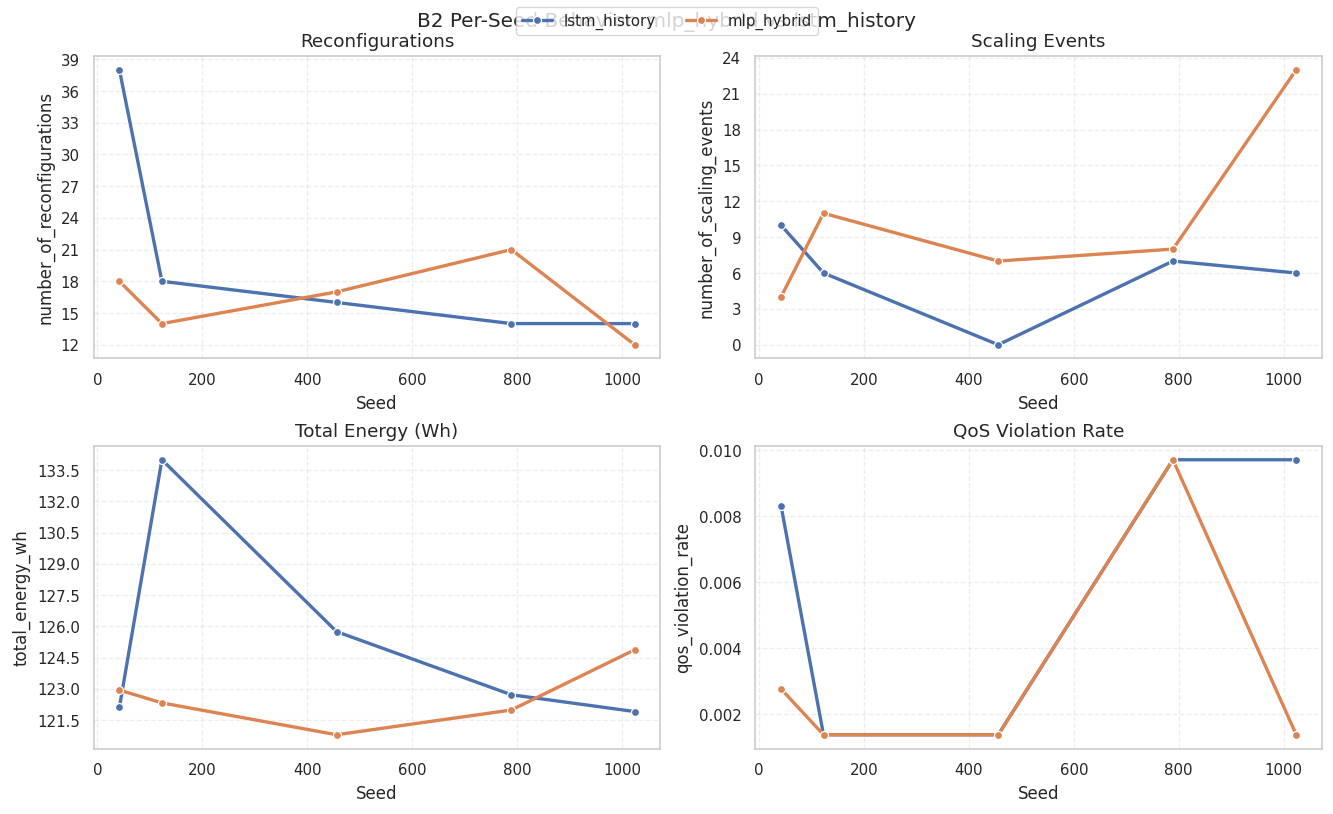

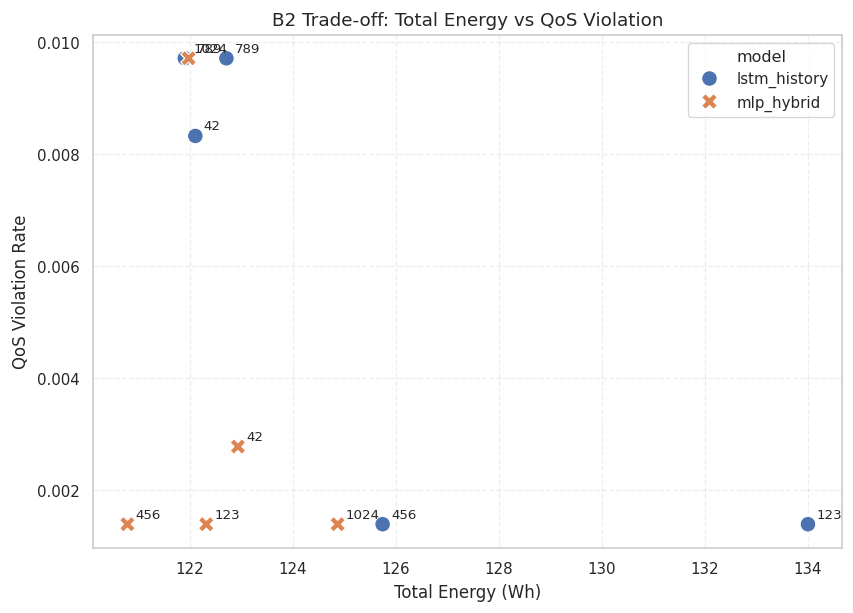

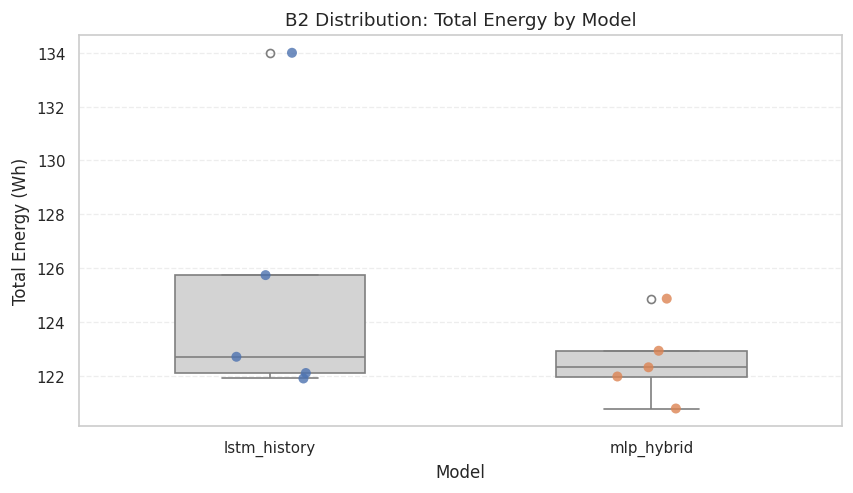

Saved: ../experiments/results/B2_top2_seeds/paper_figures/b2_seed_trends.png
Saved: ../experiments/results/B2_top2_seeds/paper_figures/b2_seed_trends.pdf
Saved: ../experiments/results/B2_top2_seeds/paper_figures/b2_energy_vs_violation_scatter.png
Saved: ../experiments/results/B2_top2_seeds/paper_figures/b2_energy_vs_violation_scatter.pdf
Saved: ../experiments/results/B2_top2_seeds/paper_figures/b2_energy_distribution.png
Saved: ../experiments/results/B2_top2_seeds/paper_figures/b2_energy_distribution.pdf


In [49]:
assert 'per_seed_b2' in globals() and not per_seed_b2.empty, 'Run B2 comparison cells first'

import seaborn as sns
import matplotlib.pyplot as plt

plot_df = per_seed_b2.copy()
plot_df['seed_num'] = plot_df['seed'].astype(str).str.replace('seed_', '', regex=False).astype(int)
plot_df = plot_df.sort_values(['model', 'seed_num']).reset_index(drop=True)

b2_fig_dir = RUNS_ROOT_B2 / 'paper_figures'
b2_fig_dir.mkdir(parents=True, exist_ok=True)

# 1) Per-seed trends (small multiples)
metrics_plot = [
    ('number_of_reconfigurations', 'Reconfigurations'),
    ('number_of_scaling_events', 'Scaling Events'),
    ('total_energy_wh', 'Total Energy (Wh)'),
    ('qos_violation_rate', 'QoS Violation Rate'),
]

fig, axes = plt.subplots(2, 2, figsize=(11, 6.5), constrained_layout=True)
for ax, (col, title) in zip(axes.flat, metrics_plot):
    sns.lineplot(data=plot_df, x='seed_num', y=col, hue='model', marker='o', linewidth=2, ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Seed')
    ax.grid(True, linestyle='--', alpha=0.35)
    if col != 'qos_violation_rate':
        ax.get_yaxis().set_major_locator(plt.MaxNLocator(integer=False))

handles, labels = axes.flat[0].get_legend_handles_labels()
for ax in axes.flat:
    leg = ax.get_legend()
    if leg:
        leg.remove()
fig.legend(handles, labels, loc='upper center', ncol=2, frameon=True)
fig.suptitle('B2 Per-Seed Behavior: mlp_hybrid vs lstm_history', y=1.02)

fig1_png = b2_fig_dir / 'b2_seed_trends.png'
fig1_pdf = b2_fig_dir / 'b2_seed_trends.pdf'
fig.savefig(fig1_png, bbox_inches='tight')
fig.savefig(fig1_pdf, bbox_inches='tight')
plt.show()

# 2) Trade-off scatter: energy vs violation, label by seed
fig2, ax2 = plt.subplots(figsize=(7, 5), constrained_layout=True)
sns.scatterplot(
    data=plot_df,
    x='total_energy_wh',
    y='qos_violation_rate',
    hue='model',
    style='model',
    s=90,
    ax=ax2,
)
for _, r in plot_df.iterrows():
    ax2.annotate(str(r['seed_num']), (r['total_energy_wh'], r['qos_violation_rate']), textcoords='offset points', xytext=(5, 4), fontsize=8)
ax2.set_title('B2 Trade-off: Total Energy vs QoS Violation')
ax2.set_xlabel('Total Energy (Wh)')
ax2.set_ylabel('QoS Violation Rate')
ax2.grid(True, linestyle='--', alpha=0.35)

fig2_png = b2_fig_dir / 'b2_energy_vs_violation_scatter.png'
fig2_pdf = b2_fig_dir / 'b2_energy_vs_violation_scatter.pdf'
fig2.savefig(fig2_png, bbox_inches='tight')
fig2.savefig(fig2_pdf, bbox_inches='tight')
plt.show()

# 3) Distribution view for total energy
fig3, ax3 = plt.subplots(figsize=(7, 4), constrained_layout=True)
sns.boxplot(data=plot_df, x='model', y='total_energy_wh', ax=ax3, color='lightgray', width=0.5)
sns.stripplot(data=plot_df, x='model', y='total_energy_wh', hue='model', dodge=False, size=6, alpha=0.8, ax=ax3)
leg3 = ax3.get_legend()
if leg3:
    leg3.remove()
ax3.set_title('B2 Distribution: Total Energy by Model')
ax3.set_xlabel('Model')
ax3.set_ylabel('Total Energy (Wh)')
ax3.grid(True, axis='y', linestyle='--', alpha=0.35)

fig3_png = b2_fig_dir / 'b2_energy_distribution.png'
fig3_pdf = b2_fig_dir / 'b2_energy_distribution.pdf'
fig3.savefig(fig3_png, bbox_inches='tight')
fig3.savefig(fig3_pdf, bbox_inches='tight')
plt.show()

print(f'Saved: {fig1_png}')
print(f'Saved: {fig1_pdf}')
print(f'Saved: {fig2_png}')
print(f'Saved: {fig2_pdf}')
print(f'Saved: {fig3_png}')
print(f'Saved: {fig3_pdf}')

## Additional B2 plots

Added views:
1. QoS violation distribution by model (box + points)
2. Reconfiguration vs scaling scatter (seed-labeled)

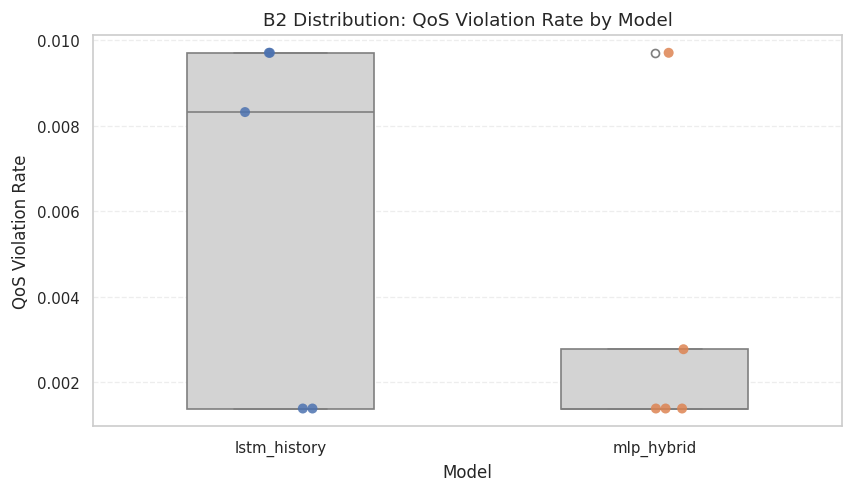

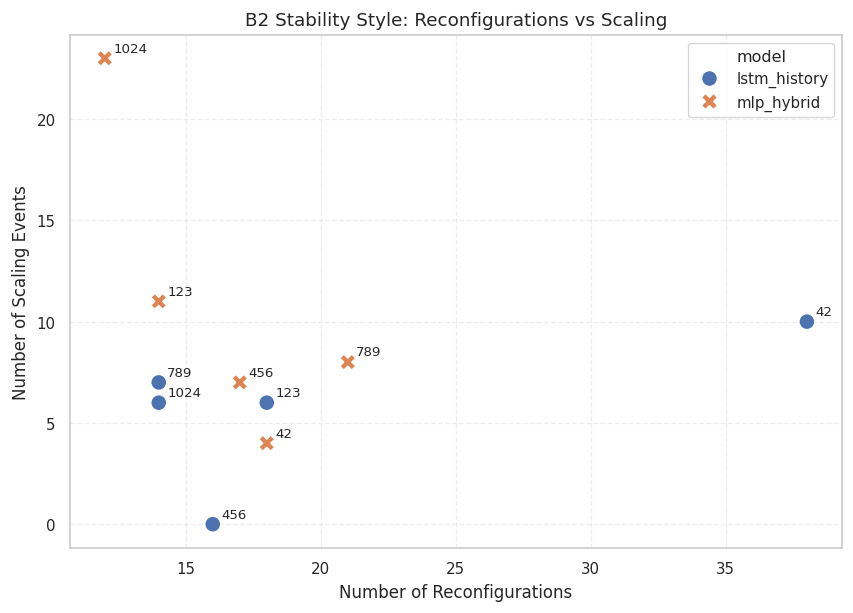

Saved: ../experiments/results/B2_top2_seeds/paper_figures/b2_qos_violation_distribution.png
Saved: ../experiments/results/B2_top2_seeds/paper_figures/b2_qos_violation_distribution.pdf
Saved: ../experiments/results/B2_top2_seeds/paper_figures/b2_reconfig_vs_scaling_scatter.png
Saved: ../experiments/results/B2_top2_seeds/paper_figures/b2_reconfig_vs_scaling_scatter.pdf


In [50]:
assert 'per_seed_b2' in globals() and not per_seed_b2.empty, 'Run B2 comparison cells first'

plot_df_extra = per_seed_b2.copy()
plot_df_extra['seed_num'] = plot_df_extra['seed'].astype(str).str.replace('seed_', '', regex=False).astype(int)
b2_fig_dir = RUNS_ROOT_B2 / 'paper_figures'
b2_fig_dir.mkdir(parents=True, exist_ok=True)

# 1) QoS violation distribution
fig4, ax4 = plt.subplots(figsize=(7, 4), constrained_layout=True)
sns.boxplot(data=plot_df_extra, x='model', y='qos_violation_rate', ax=ax4, color='lightgray', width=0.5)
sns.stripplot(data=plot_df_extra, x='model', y='qos_violation_rate', hue='model', dodge=False, size=6, alpha=0.85, ax=ax4)
leg4 = ax4.get_legend()
if leg4:
    leg4.remove()
ax4.set_title('B2 Distribution: QoS Violation Rate by Model')
ax4.set_xlabel('Model')
ax4.set_ylabel('QoS Violation Rate')
ax4.grid(True, axis='y', linestyle='--', alpha=0.35)

fig4_png = b2_fig_dir / 'b2_qos_violation_distribution.png'
fig4_pdf = b2_fig_dir / 'b2_qos_violation_distribution.pdf'
fig4.savefig(fig4_png, bbox_inches='tight')
fig4.savefig(fig4_pdf, bbox_inches='tight')
plt.show()

# 2) Reconfigurations vs scaling scatter
fig5, ax5 = plt.subplots(figsize=(7, 5), constrained_layout=True)
sns.scatterplot(
    data=plot_df_extra,
    x='number_of_reconfigurations',
    y='number_of_scaling_events',
    hue='model',
    style='model',
    s=90,
    ax=ax5,
)
for _, rr in plot_df_extra.iterrows():
    ax5.annotate(str(rr['seed_num']), (rr['number_of_reconfigurations'], rr['number_of_scaling_events']), textcoords='offset points', xytext=(5, 4), fontsize=8)
ax5.set_title('B2 Stability Style: Reconfigurations vs Scaling')
ax5.set_xlabel('Number of Reconfigurations')
ax5.set_ylabel('Number of Scaling Events')
ax5.grid(True, linestyle='--', alpha=0.35)

fig5_png = b2_fig_dir / 'b2_reconfig_vs_scaling_scatter.png'
fig5_pdf = b2_fig_dir / 'b2_reconfig_vs_scaling_scatter.pdf'
fig5.savefig(fig5_png, bbox_inches='tight')
fig5.savefig(fig5_pdf, bbox_inches='tight')
plt.show()

print(f'Saved: {fig4_png}')
print(f'Saved: {fig4_pdf}')
print(f'Saved: {fig5_png}')
print(f'Saved: {fig5_pdf}')

## C1 Sensitivity Analysis (cooldown + instance count)

This section is additive-only and does not modify prior A1/B2 analyses.

Goal:
- Sensitivity to cooldown with fixed instances (`k=2`): `cd0_k2`, `cd2_k2`, `cd4_k2`, `cd8_k2`
- Sensitivity to instances at fixed cooldown (`cd=4`): `k=2` vs `k=1`

Outputs are written under `experiments/results/C1_cooldown_instances/analysis` and figures under `experiments/results/C1_cooldown_instances/paper_figures`.

In [63]:
# Discover latest evaluation CSV per C1 run and compute per-run metrics
RUNS_ROOT_C1 = Path('../experiments/results/C1_cooldown_instances')
latest_per_run_c1 = find_latest_eval_csv_per_run(RUNS_ROOT_C1)

print(f'C1 runs root: {RUNS_ROOT_C1.resolve()}')
print(f'Latest eval CSV files discovered: {len(latest_per_run_c1)}')

rows_c1 = [compute_run_metrics(csv_path) for csv_path in sorted(latest_per_run_c1.values())]
summary_df_c1 = pd.DataFrame(rows_c1)

if not summary_df_c1.empty:
    summary_df_c1 = summary_df_c1.sort_values(['group', 'config', 'seed']).reset_index(drop=True)

print(f'Found {len(summary_df_c1)} C1 runs with evaluation CSVs')
display(summary_df_c1)

C1 runs root: /home/ubuntu/EnergyAwareUPF/experiments/results/C1_cooldown_instances
Latest eval CSV files discovered: 5
Found 5 C1 runs with evaluation CSVs


,group,config,seed,run_dir,eval_csv,steps,switch_dpdk_to_oai,switch_oai_to_dpdk,scale_up,scale_down,cooldown_blocked,avg_sec,total_power,violation_rate,avg_qos,qos_threshold
0,C1_cooldown_instances,cd0_k2,seed_456,../experiments/results/C1_cooldown_instances/c...,../experiments/results/C1_cooldown_instances/c...,721,18,18,5,5,0,0.007184,481.121771,0.009709,0.951875,0.9
1,C1_cooldown_instances,cd2_k2,seed_456,../experiments/results/C1_cooldown_instances/c...,../experiments/results/C1_cooldown_instances/c...,721,8,9,7,0,5,0.007445,485.717952,0.001387,0.956655,0.9
2,C1_cooldown_instances,cd4_k1,seed_456,../experiments/results/C1_cooldown_instances/c...,../experiments/results/C1_cooldown_instances/c...,721,10,10,0,0,3,0.007490,493.290473,0.001387,0.953919,0.9
3,C1_cooldown_instances,cd4_k2,seed_456,../experiments/results/C1_cooldown_instances/c...,../experiments/results/C1_cooldown_instances/c...,721,8,9,7,0,3,0.007350,483.160035,0.001387,0.954665,0.9
4,C1_cooldown_instances,cd8_k2,seed_456,../experiments/results/C1_cooldown_instances/c...,../experiments/results/C1_cooldown_instances/c...,721,9,9,13,9,90,0.007324,486.169247,0.004161,0.951998,0.9


In [64]:
# Build C1 summary tables and export
out_c1 = Path('../experiments/results/C1_cooldown_instances/analysis')
out_c1.mkdir(parents=True, exist_ok=True)

metrics_c1 = [
    'total_power', 'avg_sec', 'avg_qos', 'violation_rate',
    'switch_dpdk_to_oai', 'switch_oai_to_dpdk', 'scale_up',
    'scale_down', 'cooldown_blocked'
]

summary_df_c1.to_csv(out_c1 / 'c1_per_run_summary.csv', index=False)

if not summary_df_c1.empty:
    stats_c1 = (
        summary_df_c1.groupby('config')[metrics_c1]
        .agg(['mean', 'std'])
        .sort_index()
    )
else:
    stats_c1 = pd.DataFrame()

stats_c1.to_csv(out_c1 / 'c1_config_stats.csv')

# Cooldown sensitivity subset (k=2 only)
cooldown_order = ['cd0_k2', 'cd2_k2', 'cd4_k2', 'cd8_k2']
cd_sens = summary_df_c1[summary_df_c1['config'].isin(cooldown_order)].copy()
if not cd_sens.empty:
    cd_sens['cooldown'] = cd_sens['config'].str.extract(r'cd(\d+)_k2').astype(float)
    cd_sens = cd_sens.sort_values('cooldown').reset_index(drop=True)
else:
    cd_sens = pd.DataFrame(columns=['config', 'cooldown'] + metrics_c1)
cd_sens.to_csv(out_c1 / 'c1_cooldown_sensitivity_k2.csv', index=False)

# Instance sensitivity at cooldown=4
inst_sens = summary_df_c1[summary_df_c1['config'].isin(['cd4_k2', 'cd4_k1'])].copy()
if not inst_sens.empty:
    inst_sens['instances'] = inst_sens['config'].str.extract(r'_k(\d+)').astype(float)
    inst_sens = inst_sens.sort_values('instances').reset_index(drop=True)
else:
    inst_sens = pd.DataFrame(columns=['config', 'instances'] + metrics_c1)
inst_sens.to_csv(out_c1 / 'c1_instance_sensitivity_cd4.csv', index=False)

print('Saved C1 analysis CSVs to', out_c1.resolve())
display(cd_sens[['config', 'cooldown'] + metrics_c1] if not cd_sens.empty else cd_sens)
display(inst_sens[['config', 'instances'] + metrics_c1] if not inst_sens.empty else inst_sens)

Saved C1 analysis CSVs to /home/ubuntu/EnergyAwareUPF/experiments/results/C1_cooldown_instances/analysis


,config,cooldown,total_power,avg_sec,avg_qos,violation_rate,switch_dpdk_to_oai,switch_oai_to_dpdk,scale_up,scale_down,cooldown_blocked
0,cd0_k2,0.0,481.121771,0.007184,0.951875,0.009709,18,18,5,5,0
1,cd2_k2,2.0,485.717952,0.007445,0.956655,0.001387,8,9,7,0,5
2,cd4_k2,4.0,483.160035,0.007350,0.954665,0.001387,8,9,7,0,3
3,cd8_k2,8.0,486.169247,0.007324,0.951998,0.004161,9,9,13,9,90


,config,instances,total_power,avg_sec,avg_qos,violation_rate,switch_dpdk_to_oai,switch_oai_to_dpdk,scale_up,scale_down,cooldown_blocked
0,cd4_k1,1.0,493.290473,0.00749,0.953919,0.001387,10,10,0,0,3
1,cd4_k2,2.0,483.160035,0.00735,0.954665,0.001387,8,9,7,0,3


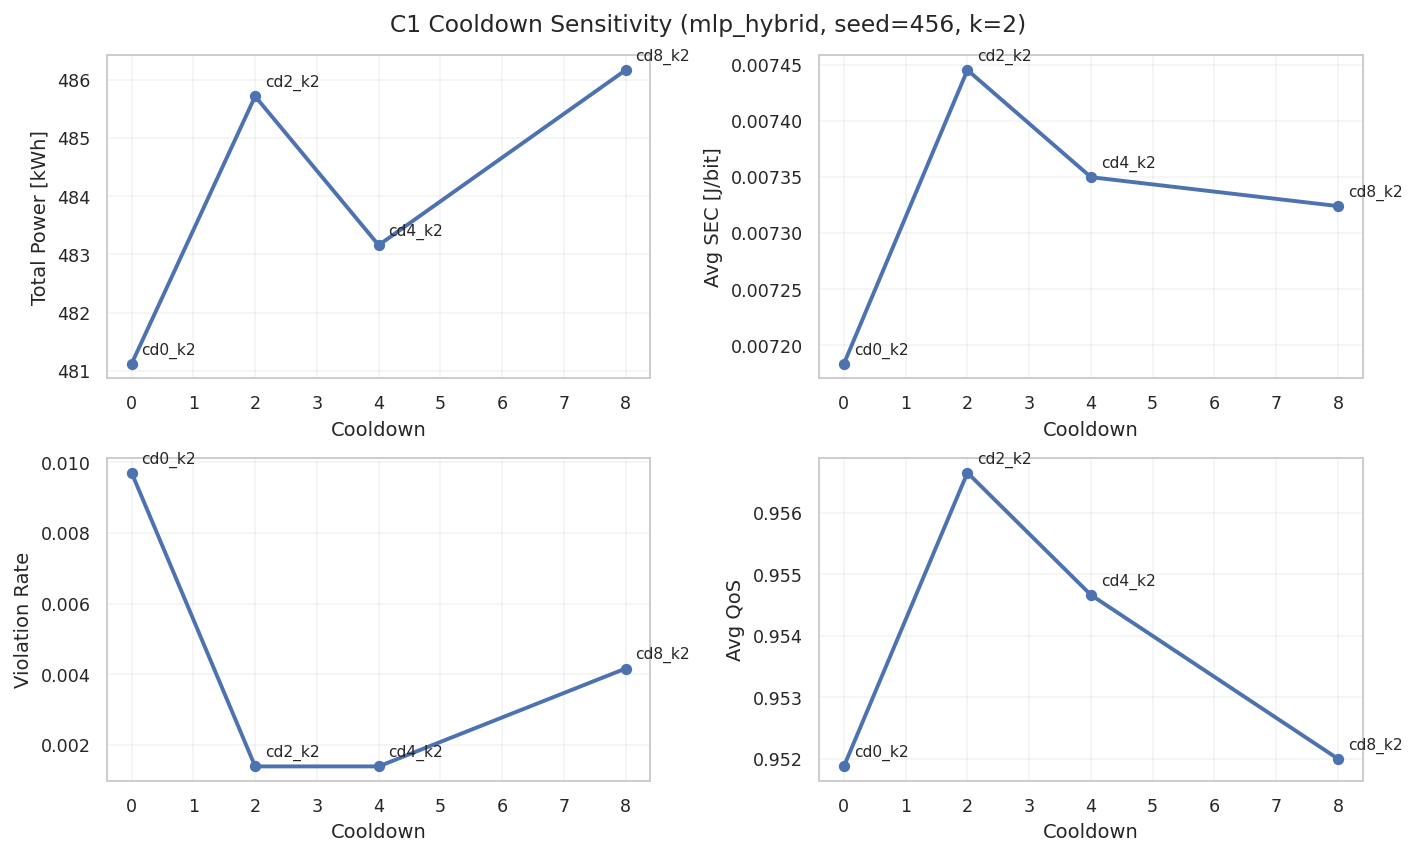

Saved: /home/ubuntu/EnergyAwareUPF/experiments/results/C1_cooldown_instances/paper_figures/fig_c1_cooldown_sensitivity_k2.png and /home/ubuntu/EnergyAwareUPF/experiments/results/C1_cooldown_instances/paper_figures/fig_c1_cooldown_sensitivity_k2.pdf


/tmp/ipykernel_553281/1366793254.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=inst_sens, x='config', y=m, ax=ax, palette='deep')
/tmp/ipykernel_553281/1366793254.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=inst_sens, x='config', y=m, ax=ax, palette='deep')
/tmp/ipykernel_553281/1366793254.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=inst_sens, x='config', y=m, ax=ax, palette='deep')
/tmp/ipykernel_553281/1366793254.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will

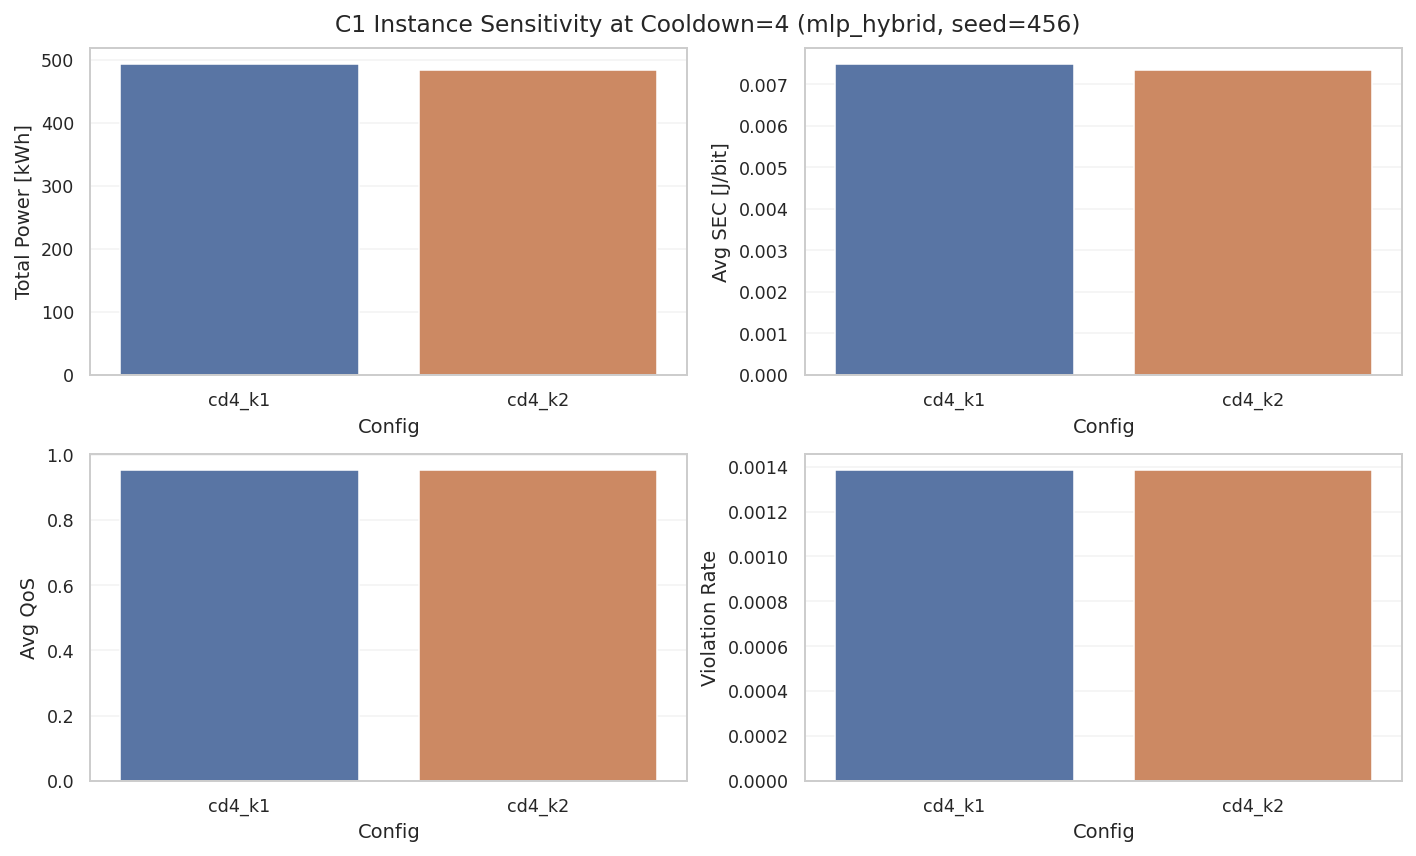

Saved: /home/ubuntu/EnergyAwareUPF/experiments/results/C1_cooldown_instances/paper_figures/fig_c1_instance_sensitivity_cd4.png and /home/ubuntu/EnergyAwareUPF/experiments/results/C1_cooldown_instances/paper_figures/fig_c1_instance_sensitivity_cd4.pdf


In [62]:
# Plot C1 sensitivity figures
c1_fig_dir = Path('../experiments/results/C1_cooldown_instances/paper_figures')
c1_fig_dir.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({'figure.dpi': 140})

if cd_sens.empty or inst_sens.empty:
    print('Insufficient C1 data for plotting. Check C1 eval CSV discovery first.')
else:
    # A) Cooldown sensitivity curves for k=2
    metrics_plot_c1 = [
        ('total_power', 'Total Power [kWh]'),
        ('avg_sec', 'Avg SEC [J/bit]'),
        ('violation_rate', 'Violation Rate'),
        ('avg_qos', 'Avg QoS')
    ]

    fig, axes = plt.subplots(2, 2, figsize=(10, 6), constrained_layout=True)
    for ax, (m, label) in zip(axes.ravel(), metrics_plot_c1):
        ax.plot(cd_sens['cooldown'], cd_sens[m], marker='o', linewidth=2)
        for _, rr in cd_sens.iterrows():
            ax.annotate(rr['config'], (rr['cooldown'], rr[m]), textcoords='offset points', xytext=(5, 5), fontsize=8)
        ax.set_xlabel('Cooldown')
        ax.set_ylabel(label)
        ax.grid(alpha=0.25)

    fig.suptitle('C1 Cooldown Sensitivity (mlp_hybrid, seed=456, k=2)', fontsize=12)
    fig_cd_png = c1_fig_dir / 'fig_c1_cooldown_sensitivity_k2.png'
    fig_cd_pdf = c1_fig_dir / 'fig_c1_cooldown_sensitivity_k2.pdf'
    fig.savefig(fig_cd_png, bbox_inches='tight')
    fig.savefig(fig_cd_pdf, bbox_inches='tight')
    plt.show()
    print('Saved:', fig_cd_png.resolve(), 'and', fig_cd_pdf.resolve())

    # B) Instance sensitivity at cd=4 (k=1 vs k=2)
    comp_metrics = [
        ('total_power', 'Total Power [kWh]'),
        ('avg_sec', 'Avg SEC [J/bit]'),
        ('avg_qos', 'Avg QoS'),
        ('violation_rate', 'Violation Rate'),
    ]

    fig2, axes2 = plt.subplots(2, 2, figsize=(10, 6), constrained_layout=True)
    for ax, (m, label) in zip(axes2.ravel(), comp_metrics):
        sns.barplot(data=inst_sens, x='config', y=m, ax=ax, palette='deep')
        ax.set_xlabel('Config')
        ax.set_ylabel(label)
        ax.grid(axis='y', alpha=0.25)

    fig2.suptitle('C1 Instance Sensitivity at Cooldown=4 (mlp_hybrid, seed=456)', fontsize=12)
    fig_inst_png = c1_fig_dir / 'fig_c1_instance_sensitivity_cd4.png'
    fig_inst_pdf = c1_fig_dir / 'fig_c1_instance_sensitivity_cd4.pdf'
    fig2.savefig(fig_inst_png, bbox_inches='tight')
    fig2.savefig(fig_inst_pdf, bbox_inches='tight')
    plt.show()
    print('Saved:', fig_inst_png.resolve(), 'and', fig_inst_pdf.resolve())

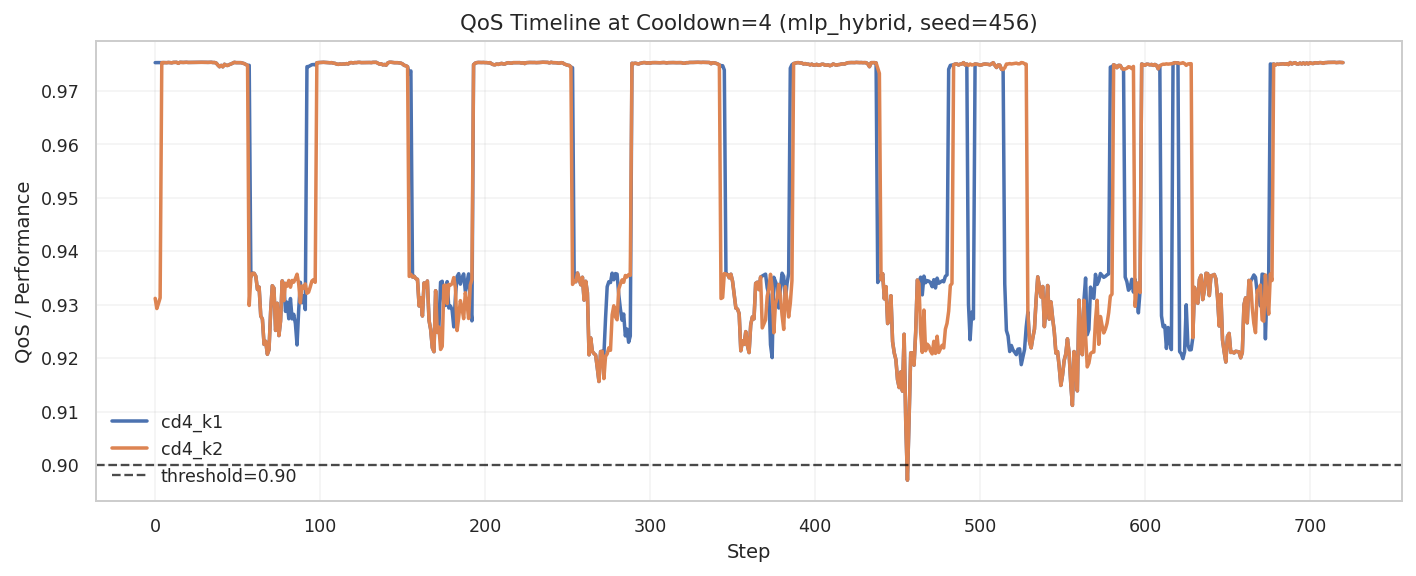

Saved: /home/ubuntu/EnergyAwareUPF/experiments/results/C1_cooldown_instances/paper_figures/fig_c1_qos_timeline_cd4_k1_vs_k2.png and /home/ubuntu/EnergyAwareUPF/experiments/results/C1_cooldown_instances/paper_figures/fig_c1_qos_timeline_cd4_k1_vs_k2.pdf


In [66]:
# QoS timeline comparison for cooldown=4: k=1 vs k=2
cfg_targets = ['cd4_k1', 'cd4_k2']

if 'summary_df_c1' not in globals() or summary_df_c1.empty:
    raise RuntimeError('summary_df_c1 is missing/empty. Run the C1 discovery cell first.')

subset_cd4 = summary_df_c1[summary_df_c1['config'].isin(cfg_targets)].copy()
if subset_cd4.empty or subset_cd4['config'].nunique() < 2:
    raise RuntimeError('Could not find both cd4_k1 and cd4_k2 in C1 results.')

# Ensure output directory exists
if 'c1_fig_dir' not in globals():
    c1_fig_dir = Path('../experiments/results/C1_cooldown_instances/paper_figures')
c1_fig_dir.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(10, 4), constrained_layout=True)

for cfg in cfg_targets:
    row = subset_cd4[subset_cd4['config'] == cfg].iloc[0]
    eval_csv = Path(row['eval_csv'])
    if not eval_csv.exists():
        raise FileNotFoundError(f'Missing eval CSV: {eval_csv}')

    df_cfg = pd.read_csv(eval_csv)
    qos_col = 'performance' if 'performance' in df_cfg.columns else ('qos' if 'qos' in df_cfg.columns else None)
    if qos_col is None:
        raise RuntimeError(f'No QoS/performance column found in {eval_csv}')

    qos_series = pd.to_numeric(df_cfg[qos_col], errors='coerce')
    ax.plot(qos_series.index, qos_series.values, label=cfg, linewidth=1.8)

if 'qos_threshold' in subset_cd4.columns and subset_cd4['qos_threshold'].notna().any():
    thr = float(subset_cd4['qos_threshold'].dropna().iloc[0])
    ax.axhline(thr, linestyle='--', linewidth=1.2, color='black', alpha=0.7, label=f'threshold={thr:.2f}')

ax.set_title('QoS Timeline at Cooldown=4 (mlp_hybrid, seed=456)')
ax.set_xlabel('Step')
ax.set_ylabel('QoS / Performance')
ax.grid(alpha=0.25)
ax.legend(frameon=False)

qos_tl_png = c1_fig_dir / 'fig_c1_qos_timeline_cd4_k1_vs_k2.png'
qos_tl_pdf = c1_fig_dir / 'fig_c1_qos_timeline_cd4_k1_vs_k2.pdf'
fig.savefig(qos_tl_png, bbox_inches='tight')
fig.savefig(qos_tl_pdf, bbox_inches='tight')
plt.show()
print('Saved:', qos_tl_png.resolve(), 'and', qos_tl_pdf.resolve())

## D1 Comparison: MLP vs LSTM (cd=4, k in {1,2}, threshold in {0.90,0.95})

Additive-only section for D1 results under `experiments/results/D1_mlp_lstm_cd4_k_threshold`.

This section:
- Loads latest eval CSV per run
- Builds per-run comparison table
- Compares policy effect at fixed `(k, threshold)`
- Saves D1-specific tables and figures

In [3]:
from pathlib import Path
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


def _extract_timestamp_from_name(path: Path) -> str:
    m = re.search(r'(\d{8}-\d{6})', path.name)
    return m.group(1) if m else ''


def find_latest_eval_csv_per_run(root: Path) -> dict[Path, Path]:
    all_csvs = sorted(root.rglob('evaluation_results*.csv'))
    latest = {}
    for csv_path in all_csvs:
        if csv_path.parent.name != 'eval':
            continue
        run_dir = csv_path.parent.parent
        if run_dir not in latest:
            latest[run_dir] = csv_path
            continue
        current = latest[run_dir]
        t_new = _extract_timestamp_from_name(csv_path)
        t_old = _extract_timestamp_from_name(current)
        if t_new and t_old:
            if t_new > t_old:
                latest[run_dir] = csv_path
        else:
            if csv_path.stat().st_mtime > current.stat().st_mtime:
                latest[run_dir] = csv_path
    return latest


def _compute_run_metrics(eval_csv: Path) -> dict:
    df = pd.read_csv(eval_csv)
    run_dir = eval_csv.parent.parent

    config = run_dir.parents[0].name
    seed = run_dir.name

    action = pd.to_numeric(df.get('executed_action', df.get('executed_code')), errors='coerce')
    prev = action.shift(1)
    cur = action

    switch_dpdk_to_oai = int(((prev == 0) & (cur > 0)).sum())
    switch_oai_to_dpdk = int(((prev > 0) & (cur == 0)).sum())
    scale_up = int(((prev > 0) & (cur > 0) & (cur > prev)).sum())
    scale_down = int(((prev > 0) & (cur > 0) & (cur < prev)).sum())

    if 'cooldown_blocked' in df.columns:
        cooldown_blocked = int(df['cooldown_blocked'].fillna(False).astype(bool).sum())
    else:
        cooldown_blocked = 0

    power = pd.to_numeric(df.get('power'), errors='coerce')
    perf = pd.to_numeric(df.get('performance'), errors='coerce')
    sec = pd.to_numeric(df.get('sec'), errors='coerce')

    # Parse D1 config name: <policy>_..._k<k>_t<thr>
    pol = 'lstm' if config.startswith('lstm') else 'mlp'
    km = re.search(r'_k(\d+)_', config)
    tm = re.search(r'_t(\d+)$', config)
    k = int(km.group(1)) if km else np.nan
    thr = (float(tm.group(1)) / 100.0) if tm else np.nan

    violation_rate = float((perf < thr).mean()) if perf.notna().any() and not np.isnan(thr) else np.nan

    return {
        'config': config,
        'policy': pol,
        'k': k,
        'threshold': thr,
        'seed': seed,
        'steps': int(len(df)),
        'switch_dpdk_to_oai': switch_dpdk_to_oai,
        'switch_oai_to_dpdk': switch_oai_to_dpdk,
        'scale_up': scale_up,
        'scale_down': scale_down,
        'cooldown_blocked': cooldown_blocked,
        'avg_sec': float(sec.mean()) if sec.notna().any() else np.nan,
        'total_power': float(power.sum()) if power.notna().any() else np.nan,
        'avg_qos': float(perf.mean()) if perf.notna().any() else np.nan,
        'violation_rate': violation_rate,
        'eval_csv': str(eval_csv),
    }


RUNS_ROOT_D1 = Path('../experiments/results/D1_mlp_lstm_cd4_k_threshold')
assert RUNS_ROOT_D1.exists(), f'D1 root not found: {RUNS_ROOT_D1.resolve()}'

latest_per_run_d1 = find_latest_eval_csv_per_run(RUNS_ROOT_D1)
rows_d1 = [_compute_run_metrics(p) for p in sorted(latest_per_run_d1.values())]
summary_df_d1 = pd.DataFrame(rows_d1).sort_values(['policy', 'k', 'threshold']).reset_index(drop=True)

out_d1 = RUNS_ROOT_D1 / 'analysis'
out_d1.mkdir(parents=True, exist_ok=True)
summary_df_d1.to_csv(out_d1 / 'd1_per_run_summary.csv', index=False)

print(f'Found {len(summary_df_d1)} D1 run(s)')
display(summary_df_d1[['config','policy','k','threshold','avg_sec','total_power','avg_qos','violation_rate','switch_dpdk_to_oai','switch_oai_to_dpdk','scale_up','scale_down','cooldown_blocked']].round(4))

# Pairwise MLP vs LSTM deltas at fixed (k, threshold)
pivot_idx = ['k', 'threshold']
metrics_cmp = ['avg_sec', 'total_power', 'avg_qos', 'violation_rate', 'cooldown_blocked']
wide = summary_df_d1.pivot_table(index=pivot_idx, columns='policy', values=metrics_cmp, aggfunc='first')

for m in metrics_cmp:
    if (m, 'mlp') in wide.columns and (m, 'lstm') in wide.columns:
        wide[(f'delta_{m}', 'mlp_minus_lstm')] = wide[(m, 'mlp')] - wide[(m, 'lstm')]

wide.columns = [f'{a}__{b}' for a, b in wide.columns]
wide = wide.reset_index().sort_values(['k', 'threshold'])
wide.to_csv(out_d1 / 'd1_policy_delta_table.csv', index=False)

print('Saved D1 tables to', out_d1.resolve())
display(wide.round(5))

Found 8 D1 run(s)


,config,policy,k,threshold,avg_sec,total_power,avg_qos,violation_rate,switch_dpdk_to_oai,switch_oai_to_dpdk,scale_up,scale_down,cooldown_blocked
0,lstm_history_cd4_k1_t90,lstm,1,0.90,0.0075,487.2124,0.9587,0.0014,7,7,0,0,2
1,lstm_history_cd4_k1_t95,lstm,1,0.95,0.0082,511.7571,0.9646,0.2080,7,7,0,0,0
2,lstm_history_cd4_k2_t90,lstm,2,0.90,0.0076,502.9746,0.9552,0.0014,8,8,0,0,7
3,lstm_history_cd4_k2_t95,lstm,2,0.95,0.0077,495.6476,0.9610,0.2968,8,8,0,0,7
4,mlp_hybrid_cd4_k1_t90,mlp,1,0.90,0.0075,493.2905,0.9539,0.0014,10,10,0,0,3
5,mlp_hybrid_cd4_k1_t95,mlp,1,0.95,0.0088,517.9402,0.9650,0.2025,6,6,0,0,0
6,mlp_hybrid_cd4_k2_t90,mlp,2,0.90,0.0073,483.1600,0.9547,0.0014,8,9,7,0,3
7,mlp_hybrid_cd4_k2_t95,mlp,2,0.95,0.0076,491.0399,0.9579,0.3689,9,9,1,0,9


Saved D1 tables to /home/ubuntu/EnergyAwareUPF/experiments/results/D1_mlp_lstm_cd4_k_threshold/analysis


,k,threshold,avg_qos__lstm,avg_qos__mlp,avg_sec__lstm,avg_sec__mlp,cooldown_blocked__lstm,cooldown_blocked__mlp,total_power__lstm,total_power__mlp,violation_rate__lstm,violation_rate__mlp,delta_avg_sec__mlp_minus_lstm,delta_total_power__mlp_minus_lstm,delta_avg_qos__mlp_minus_lstm,delta_violation_rate__mlp_minus_lstm,delta_cooldown_blocked__mlp_minus_lstm
0,1,0.90,0.95871,0.95392,0.00747,0.00749,2,3,487.21243,493.29047,0.00139,0.00139,0.00002,6.07804,-0.00479,0.00000,1
1,1,0.95,0.96465,0.96498,0.00821,0.00884,0,0,511.75705,517.94024,0.20804,0.20250,0.00063,6.18318,0.00033,-0.00555,0
2,2,0.90,0.95521,0.95466,0.00764,0.00735,7,3,502.97458,483.16003,0.00139,0.00139,-0.00029,-19.81454,-0.00055,0.00000,-4
3,2,0.95,0.96103,0.95787,0.00770,0.00758,7,9,495.64756,491.03994,0.29681,0.36893,-0.00012,-4.60762,-0.00316,0.07212,2


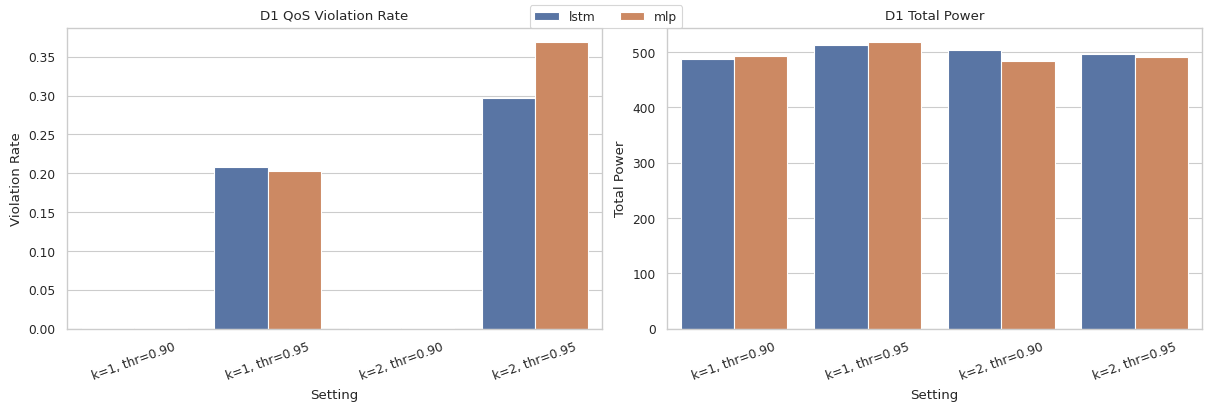

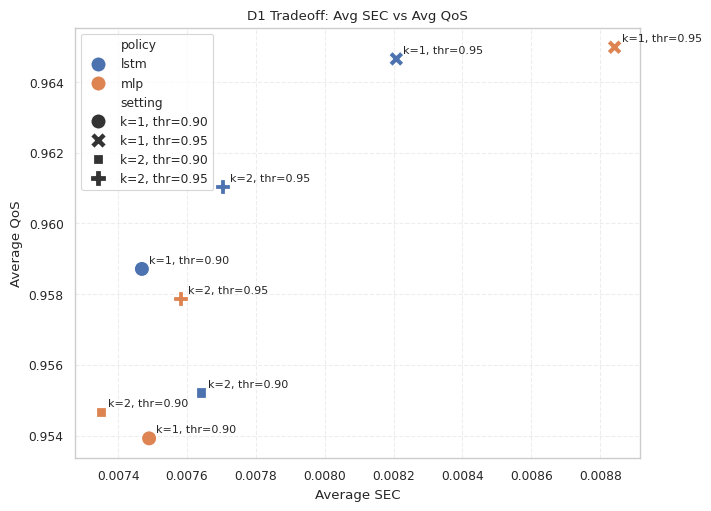

Saved: /home/ubuntu/EnergyAwareUPF/experiments/results/D1_mlp_lstm_cd4_k_threshold/paper_figures/d1_mlp_vs_lstm_violation_power.png
Saved: /home/ubuntu/EnergyAwareUPF/experiments/results/D1_mlp_lstm_cd4_k_threshold/paper_figures/d1_mlp_vs_lstm_violation_power.pdf
Saved: /home/ubuntu/EnergyAwareUPF/experiments/results/D1_mlp_lstm_cd4_k_threshold/paper_figures/d1_mlp_vs_lstm_sec_qos_tradeoff.png
Saved: /home/ubuntu/EnergyAwareUPF/experiments/results/D1_mlp_lstm_cd4_k_threshold/paper_figures/d1_mlp_vs_lstm_sec_qos_tradeoff.pdf


In [4]:
# D1 comparison plots
assert 'summary_df_d1' in globals() and not summary_df_d1.empty, 'Run D1 summary cell first'

sns.set_theme(style='whitegrid', context='paper')
d1_fig_dir = Path('../experiments/results/D1_mlp_lstm_cd4_k_threshold/paper_figures')
d1_fig_dir.mkdir(parents=True, exist_ok=True)

plot_df_d1 = summary_df_d1.copy()
plot_df_d1['setting'] = plot_df_d1.apply(lambda r: f"k={int(r['k'])}, thr={r['threshold']:.2f}", axis=1)

# 1) Violation rate and power by setting
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

sns.barplot(data=plot_df_d1, x='setting', y='violation_rate', hue='policy', ax=axes[0])
axes[0].set_title('D1 QoS Violation Rate')
axes[0].set_xlabel('Setting')
axes[0].set_ylabel('Violation Rate')
axes[0].tick_params(axis='x', rotation=20)

sns.barplot(data=plot_df_d1, x='setting', y='total_power', hue='policy', ax=axes[1])
axes[1].set_title('D1 Total Power')
axes[1].set_xlabel('Setting')
axes[1].set_ylabel('Total Power')
axes[1].tick_params(axis='x', rotation=20)

# keep single legend outside for cleanliness
handles, labels = axes[0].get_legend_handles_labels()
for ax in axes:
    lg = ax.get_legend()
    if lg:
        lg.remove()
fig.legend(handles, labels, loc='upper center', ncol=2, frameon=True)

fig1_png = d1_fig_dir / 'd1_mlp_vs_lstm_violation_power.png'
fig1_pdf = d1_fig_dir / 'd1_mlp_vs_lstm_violation_power.pdf'
fig.savefig(fig1_png, bbox_inches='tight')
fig.savefig(fig1_pdf, bbox_inches='tight')
plt.show()

# 2) SEC vs Avg QoS tradeoff scatter
fig2, ax2 = plt.subplots(figsize=(7, 5), constrained_layout=True)
sns.scatterplot(
    data=plot_df_d1,
    x='avg_sec',
    y='avg_qos',
    hue='policy',
    style='setting',
    s=120,
    ax=ax2,
)
for _, rr in plot_df_d1.iterrows():
    ax2.annotate(rr['setting'], (rr['avg_sec'], rr['avg_qos']), textcoords='offset points', xytext=(5, 4), fontsize=8)
ax2.set_title('D1 Tradeoff: Avg SEC vs Avg QoS')
ax2.set_xlabel('Average SEC')
ax2.set_ylabel('Average QoS')
ax2.grid(True, linestyle='--', alpha=0.35)

fig2_png = d1_fig_dir / 'd1_mlp_vs_lstm_sec_qos_tradeoff.png'
fig2_pdf = d1_fig_dir / 'd1_mlp_vs_lstm_sec_qos_tradeoff.pdf'
fig2.savefig(fig2_png, bbox_inches='tight')
fig2.savefig(fig2_pdf, bbox_inches='tight')
plt.show()

print('Saved:', fig1_png.resolve())
print('Saved:', fig1_pdf.resolve())
print('Saved:', fig2_png.resolve())
print('Saved:', fig2_pdf.resolve())

,system,source,switching_count,scaling_count,avg_qos,violation_rate,total_energy_wh,avg_power_w,avg_sec
0,lstm_history,D1 RL,16,0,0.955212,0.001387,125.743644,0.697607,0.007641
1,mlp_hybrid,D1 RL,17,7,0.954665,0.001387,120.790009,0.670125,0.007350
2,baseline_rule,Baseline CSV,24,0,0.960069,0.001389,123.923325,0.688463,0.007751
3,baseline_static_dpdk,Baseline CSV,0,0,0.973199,0.000000,147.586982,0.819928,0.013547
4,baseline_static_oai1x,Baseline CSV,0,0,0.924302,0.001389,178.357874,0.990877,0.009075


Saved: /home/ubuntu/EnergyAwareUPF/experiments/results/D1_mlp_lstm_cd4_k_threshold/analysis/d1_k2_t90_vs_baselines.csv


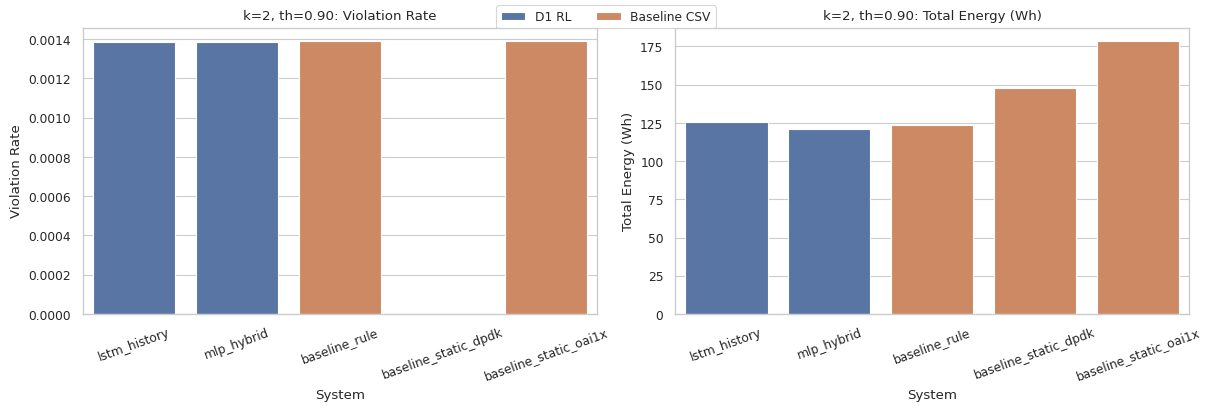

Saved: /home/ubuntu/EnergyAwareUPF/experiments/results/D1_mlp_lstm_cd4_k_threshold/paper_figures/d1_k2_t90_vs_baselines_violation_energy.png
Saved: /home/ubuntu/EnergyAwareUPF/experiments/results/D1_mlp_lstm_cd4_k_threshold/paper_figures/d1_k2_t90_vs_baselines_violation_energy.pdf


In [7]:
# D1 (k=2, th=0.90) vs Baselines comparison
from pathlib import Path
import ast
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

assert 'summary_df_d1' in globals() and not summary_df_d1.empty, 'Run the D1 summary cell first.'

# Select only the requested D1 models/settings
target = summary_df_d1[
    (summary_df_d1['k'] == 2) &
    (summary_df_d1['threshold'] == 0.90) &
    (summary_df_d1['policy'].isin(['mlp', 'lstm']))
].copy()

if target.empty:
    raise RuntimeError('No D1 rows found for k=2, threshold=0.90.')

# Build comparable D1 metrics
d1_rows = []
for _, r in target.iterrows():
    d1_rows.append({
        'system': 'mlp_hybrid' if r['policy'] == 'mlp' else 'lstm_history',
        'source': 'D1 RL',
        'switching_count': int(r['switch_dpdk_to_oai'] + r['switch_oai_to_dpdk']),
        'scaling_count': int(r['scale_up'] + r['scale_down']),
        'avg_qos': float(r['avg_qos']),
        'violation_rate': float(r['violation_rate']),
        'total_energy_wh': float(r['total_power'] * 0.25),
        'avg_power_w': float(r['total_power'] / max(r['steps'], 1)),
        'avg_sec': float(r['avg_sec']),
    })

# Baseline CSVs
baseline_dir = Path('../experiments/results/Baselines')
rule_csv = baseline_dir / 'baseline_rule_results.csv'
static_dpdk_csv = baseline_dir / 'baseline_static_dpdk_results.csv'
static_oai1x_csv = baseline_dir / 'baseline_static_oai1x_results.csv'

for p in [rule_csv, static_dpdk_csv, static_oai1x_csv]:
    if not p.exists():
        raise FileNotFoundError(f'Missing baseline file: {p}')

def _parse_upf_code(val) -> float:
    if pd.isna(val):
        return np.nan
    try:
        cfg = ast.literal_eval(str(val))
        if isinstance(cfg, tuple) and len(cfg) >= 2:
            mode = str(cfg[0]).strip().upper()
            inst = int(cfg[1])
            if mode == 'DPDK':
                return 0
            if mode == 'OAI':
                return inst
    except Exception:
        return np.nan
    return np.nan

def _pick_numeric(df: pd.DataFrame, cols: list[str]) -> pd.Series:
    for c in cols:
        if c in df.columns:
            return pd.to_numeric(df[c], errors='coerce')
    return pd.Series([np.nan] * len(df), index=df.index)

def baseline_metrics(csv_path: Path, name: str, thr: float = 0.90):
    df = pd.read_csv(csv_path)

    # QoS / energy across known baseline schemas
    qos = _pick_numeric(df, ['QoS_Score_Actual', 'QoS_Score_OAI1x'])
    energy_wh = _pick_numeric(df, ['Energy_Wh_Actual', 'Energy_Wh_OAI1x'])
    traffic = _pick_numeric(df, ['Actual_Traffic'])

    avg_qos = float(qos.mean()) if qos.notna().any() else np.nan
    violation_rate = float((qos < thr).mean()) if qos.notna().any() else np.nan

    total_energy_wh = float(energy_wh.sum()) if energy_wh.notna().any() else np.nan
    avg_power_w = float((energy_wh.mean() * 4.0)) if energy_wh.notna().any() else np.nan  # 15-min step

    if energy_wh.notna().any() and traffic.notna().any():
        power_w = energy_wh * 4.0
        avg_sec = float((power_w / np.maximum(traffic, 1e-6)).mean())
    else:
        avg_sec = np.nan

    # Switching/scaling counts from timeline columns
    if 'UPF_Config' in df.columns:
        action = df['UPF_Config'].map(_parse_upf_code)
    elif 'OAI_Instances' in df.columns:
        action = pd.to_numeric(df['OAI_Instances'], errors='coerce')
    else:
        action = pd.Series([np.nan] * len(df), index=df.index)

    if action.notna().any():
        prev = action.shift(1)
        cur = action
        switch_dpdk_to_oai = int(((prev == 0) & (cur > 0)).sum())
        switch_oai_to_dpdk = int(((prev > 0) & (cur == 0)).sum())
        scale_up = int(((prev > 0) & (cur > 0) & (cur > prev)).sum())
        scale_down = int(((prev > 0) & (cur > 0) & (cur < prev)).sum())
        switching_count = switch_dpdk_to_oai + switch_oai_to_dpdk
        scaling_count = scale_up + scale_down
    else:
        switching_count = np.nan
        scaling_count = np.nan

    return {
        'system': name,
        'source': 'Baseline CSV',
        'switching_count': switching_count,
        'scaling_count': scaling_count,
        'avg_qos': avg_qos,
        'violation_rate': violation_rate,
        'total_energy_wh': total_energy_wh,
        'avg_power_w': avg_power_w,
        'avg_sec': avg_sec,
    }

comp_rows = []
comp_rows.extend(d1_rows)
comp_rows.append(baseline_metrics(rule_csv, 'baseline_rule', thr=0.90))
comp_rows.append(baseline_metrics(static_dpdk_csv, 'baseline_static_dpdk', thr=0.90))
comp_rows.append(baseline_metrics(static_oai1x_csv, 'baseline_static_oai1x', thr=0.90))

comp_df = pd.DataFrame(comp_rows)

# Save comparison table
out_d1 = Path('../experiments/results/D1_mlp_lstm_cd4_k_threshold/analysis')
out_d1.mkdir(parents=True, exist_ok=True)
out_csv = out_d1 / 'd1_k2_t90_vs_baselines.csv'
comp_df.to_csv(out_csv, index=False)

display(comp_df.round(6))
print('Saved:', out_csv.resolve())

# Plot: QoS violation + total energy
sns.set_theme(style='whitegrid', context='paper')
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

sns.barplot(data=comp_df, x='system', y='violation_rate', hue='source', ax=axes[0])
axes[0].set_title('k=2, th=0.90: Violation Rate')
axes[0].set_xlabel('System')
axes[0].set_ylabel('Violation Rate')
axes[0].tick_params(axis='x', rotation=20)

sns.barplot(data=comp_df, x='system', y='total_energy_wh', hue='source', ax=axes[1])
axes[1].set_title('k=2, th=0.90: Total Energy (Wh)')
axes[1].set_xlabel('System')
axes[1].set_ylabel('Total Energy (Wh)')
axes[1].tick_params(axis='x', rotation=20)

# unify legend placement
handles, labels = axes[0].get_legend_handles_labels()
for ax in axes:
    lg = ax.get_legend()
    if lg:
        lg.remove()
fig.legend(handles, labels, loc='upper center', ncol=2, frameon=True)

fig_dir = Path('../experiments/results/D1_mlp_lstm_cd4_k_threshold/paper_figures')
fig_dir.mkdir(parents=True, exist_ok=True)
fig_png = fig_dir / 'd1_k2_t90_vs_baselines_violation_energy.png'
fig_pdf = fig_dir / 'd1_k2_t90_vs_baselines_violation_energy.pdf'
fig.savefig(fig_png, bbox_inches='tight')
fig.savefig(fig_pdf, bbox_inches='tight')
plt.show()

print('Saved:', fig_png.resolve())
print('Saved:', fig_pdf.resolve())